# RouteIQ

In [235]:
# Install dependencies
!pip install -q langgraph gradio openai scikit-learn nltk matplotlib seaborn google kagglehub


/usr/local/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=58823) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [236]:
# ── Download dataset and set working directory ────────────────────────────
import os
import shutil

# Download dataset via kagglehub (handles auth automatically in Colab)
import kagglehub
path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")
print(f"Dataset downloaded to: {path}")

# Set up project directories
PROJECT_DIR = os.getcwd()
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
IMAGE_DIR = os.path.join(PROJECT_DIR, 'images')
SKILLS_DIR = os.path.join(PROJECT_DIR, 'skills')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(SKILLS_DIR, exist_ok=True)

# Copy the CSV into data/ if not already there
CSV_NAME = 'aa_dataset-tickets-multi-lang-5-2-50-version.csv'
dest = os.path.join(DATA_DIR, CSV_NAME)
if not os.path.exists(dest):
    src = os.path.join(path, CSV_NAME)
    shutil.copy(src, dest)
    print(f"Copied dataset to {dest}")
else:
    print(f"Dataset already present at {dest}")

Dataset downloaded to: /Users/ying-jeanne/.cache/kagglehub/datasets/tobiasbueck/multilingual-customer-support-tickets/versions/14
Dataset already present at /Users/ying-jeanne/Workspace/dba5151/group_project/data/aa_dataset-tickets-multi-lang-5-2-50-version.csv


---
# Part 1 — Study Phase: Data Exploration & Preprocessing

> **Exploratory only — no pipeline code here.** This section documents the data analysis and preprocessing decisions made before building the pipeline. Variables defined here are not reused by the pipeline. All preprocessing is re-executed cleanly inside Node 1 (`preprocess_data`) in Part 2.

Findings informed the decisions documented in `skills/preprocess-data.md`.

In [237]:
# ── 1.1 Load raw dataset ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

df = pd.read_csv(os.path.join(DATA_DIR, CSV_NAME))
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 28,587 rows x 16 columns


## 1.2 Data Exploration

In [238]:
# ── Column types and basic info ──────────────────────────────────────────────
print('Column info:')
df.info()

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB


In [239]:
# ── Missing value audit ──────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print('Columns with missing values:')
print(missing_report)

Columns with missing values:
         Missing Count  Missing %
subject           3838       13.4
answer               7        0.0
tag_2               13        0.0
tag_3              136        0.5
tag_4             3058       10.7
tag_5            14042       49.1
tag_6            22713       79.5
tag_7            26547       92.9
tag_8            28022       98.0


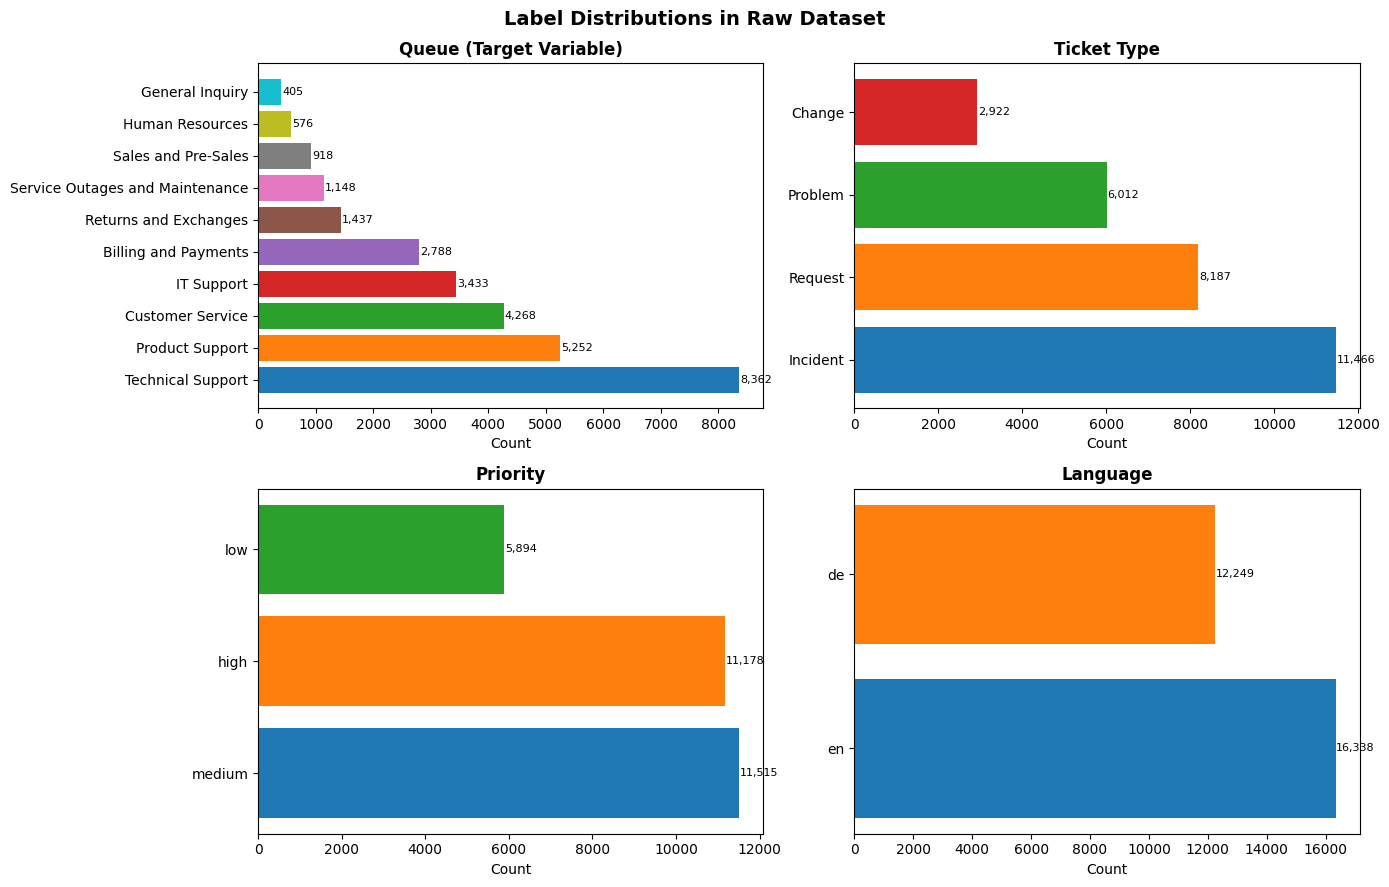

Saved: label_distributions.png


In [240]:
# ── Label distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Label Distributions in Raw Dataset', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes.flat,
    ['queue', 'type', 'priority', 'language'],
    ['Queue (Target Variable)', 'Ticket Type', 'Priority', 'Language']
):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=sns.color_palette('tab10', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'label_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distributions.png')

### Why `queue` and not `type` as the target variable?

Both `queue` and `type` describe a ticket, but they serve different purposes:

| Column | Role | Example values |
|--------|------|----------------|
| `type` | *Nature* of the request — what kind of issue it is | `question`, `problem`, `complaint` |
| `queue` | *Routing destination* — which team handles it | `Billing and Payments`, `Technical Support`, `Account Management` |

RouteIQ's goal is **automatic routing** — directing each incoming ticket to the correct support team.  
`queue` maps directly to that routing destination (10 distinct teams), making it the natural target variable.  
`type` only describes the nature of the request and carries no routing information.

**Value counts for `type`** (exploratory only, not used as target):


In [241]:
# type value counts -- exploratory only, not used as target
print('type value counts:')
print(df['type'].value_counts())
print(f"\ntype has {df['type'].nunique()} unique values; "
      f"queue has {df['queue'].nunique()} unique values."
      " queue is the routing destination — the direct target for RouteIQ.")


type value counts:
type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

type has 4 unique values; queue has 10 unique values. queue is the routing destination — the direct target for RouteIQ.


In [242]:
# Class imbalance assessment ──────────────────────────────────────────────────
queue_counts = df['queue'].value_counts()
imbalance_ratio = queue_counts.max() / queue_counts.min()
print('Queue class distribution:')
print(queue_counts)
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')
print('\nDecision: Use class_weight="balanced" during model training.')
print('This tells the model to penalise errors on minority classes more heavily,')
print('without altering the training data itself.')


Queue class distribution:
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

Imbalance ratio (max/min): 20.6x

Decision: Use class_weight="balanced" during model training.
This tells the model to penalise errors on minority classes more heavily,
without altering the training data itself.


In [243]:
# ── Text length analysis ─────────────────────────────────────────────────────
df['body_len'] = df['body'].fillna('').str.len()
df['subject_len'] = df['subject'].fillna('').str.len()

print('Body character length stats:')
print(df['body_len'].describe().round(0))
print('\nSubject character length stats:')
print(df['subject_len'].describe().round(0))

# Drop temporary columns
df.drop(columns=['body_len', 'subject_len'], inplace=True)

Body character length stats:
count    28587.0
mean       387.0
std        200.0
min          6.0
25%        219.0
50%        386.0
75%        551.0
max       1469.0
Name: body_len, dtype: float64

Subject character length stats:
count    28587.0
mean        39.0
std         24.0
min          0.0
25%         27.0
50%         39.0
75%         51.0
max        675.0
Name: subject_len, dtype: float64


## 1.3 Preprocessing

**Decisions documented here (for report & SKILL.md):**
- `subject` (3,838 missing, ~13%): fill with empty string and concatenate with `body`
- `answer` (7 missing): drop those 7 rows — too few to impute meaningfully
- `tag_1`–`tag_3`: nearly complete, but are multi-value categorical labels (e.g. "Security", "Outage") that risk target leakage and require complex multi-hot encoding — excluded
- `tag_4`–`tag_8`: >10% to >98% missing — additionally excluded
- `version`: constant value (51) — provides no signal, dropped
- Language: retain both English and German — the dataset contains 16,338 English tickets (57.2%) and 12,249 German tickets (42.8%). Filtering to English only would discard nearly half the training data. TF-IDF is language-agnostic (it treats each word as a token regardless of language), so mixing the two introduces no methodological problem. The `queue` labels are consistent across both languages, meaning routing targets are identical. Retaining both languages maximises training data volume and reflects the multilingual reality of a real-world customer support operation.

In [244]:
# ── 4.1 Drop rows where answer is missing (only 7 rows) ─────────────────────
before = len(df)
df = df.dropna(subset=['answer'])
print(f'Dropped {before - len(df)} rows with missing answer. Remaining: {len(df):,}')

# ── 4.2 Fill missing subject with empty string ────────────────────────────────
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

# ── 4.3 Combine subject + body into a single text feature ────────────────────
# Subject acts as a short title; body contains the main content.
# Concatenating gives TF-IDF access to all available text signal.
df['text'] = df['subject'].str.strip() + ' ' + df['body'].str.strip()
df['text'] = df['text'].str.strip()

# ── 4.4 Drop columns not used as features ────────────────────────────────────
cols_to_drop = ['subject', 'body', 'answer', 'version',
                'tag_1', 'tag_2', 'tag_3', 'tag_4',
                'tag_5', 'tag_6', 'tag_7', 'tag_8']
df = df.drop(columns=cols_to_drop)

print(f'\nColumns retained: {list(df.columns)}')
print(f'Final dataset shape: {df.shape}')
df.head(3)

Dropped 7 rows with missing answer. Remaining: 28,580

Columns retained: ['type', 'queue', 'priority', 'language', 'text']
Final dataset shape: (28580, 5)


,type,queue,priority,language,text
0,Incident,Technical Support,high,de,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Incident,Technical Support,high,en,"Account Disruption Dear Customer Support Team,..."
2,Request,Returns and Exchanges,medium,en,Query About Smart Home System Integration Feat...


In [245]:
# ── 4.5 Label encode the target variable (queue) ─────────────────────────────
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['queue'])

print('Queue → Encoded label mapping:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {i}: {cls}')

NUM_CLASSES = len(label_encoder.classes_)
print(f'\nTotal classes: {NUM_CLASSES}')

Queue → Encoded label mapping:
  0: Billing and Payments
  1: Customer Service
  2: General Inquiry
  3: Human Resources
  4: IT Support
  5: Product Support
  6: Returns and Exchanges
  7: Sales and Pre-Sales
  8: Service Outages and Maintenance
  9: Technical Support

Total classes: 10


## 1.4 TF-IDF Vectorisation & Train / Val / Test Split

**Split ratios:** 80% train / 10% validation / 10% test  
**Stratified** on `queue` to preserve class proportions across all three sets  
**TF-IDF fitted on training set only** — vectoriser then applied to val and test

In [246]:
# ── 5.1 Raw text / label arrays ──────────────────────────────────────────────
X_raw = df['text'].values
y = df['label'].values

# ── 5.2 First split: 90% temp + 10% test ─────────────────────────────────────
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# ── 5.3 Second split: 80% train + 10% val (from the 90% temp) ────────────────
# 0.111 of 90% ≈ 10% of total
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.111,
    stratify=y_temp,
    random_state=42
)

print(f'Train size : {len(X_train_raw):,} ({len(X_train_raw)/len(X_raw)*100:.1f}%)')
print(f'Val size   : {len(X_val_raw):,} ({len(X_val_raw)/len(X_raw)*100:.1f}%)')
print(f'Test size  : {len(X_test_raw):,} ({len(X_test_raw)/len(X_raw)*100:.1f}%)')

Train size : 22,866 (80.0%)
Val size   : 2,856 (10.0%)
Test size  : 2,858 (10.0%)


In [247]:
# Phase 1 output: compute per-sample weights from y_train
# y_train is produced by the train/val/test split cell above
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)
print(f'sample_weights computed: shape={sample_weights.shape}, '
      f'min={sample_weights.min():.4f}, max={sample_weights.max():.4f}')
print('These will be stored in agent_state and passed to Phase 2 model training.')


sample_weights computed: shape=(22866,), min=0.3418, max=7.0574
These will be stored in agent_state and passed to Phase 2 model training.


In [248]:
# ── 5.4 TF-IDF Vectorisation ─────────────────────────────────────────────────
# German stopwords (dataset is bilingual EN+DE); accent-stripped forms included
GERMAN_STOPWORDS = [
    'die', 'der', 'und', 'in', 'den', 'von', 'zu', 'das', 'mit', 'sich',
    'des', 'auf', 'fur', 'ist', 'im', 'dem', 'nicht', 'ein', 'eine', 'als',
    'auch', 'es', 'an', 'werden', 'aus', 'er', 'hat', 'dass', 'sie', 'nach',
    'wird', 'bei', 'einer', 'um', 'am', 'sind', 'noch', 'wie', 'einem',
    'uber', 'einen', 'so', 'zum', 'haben', 'oder', 'ich', 'wir', 'kann',
    'durch', 'wenn', 'aber', 'dieser', 'diesem', 'diese', 'dieses',
    'mehr', 'mich', 'mir', 'uns', 'war', 'were', 'konnen', 'wurde', 'wurden'
]

# Configuration rationale:
#   max_features=10000  : keeps vocabulary manageable; avoids noise from rare terms
#   ngram_range=(1,2)   : captures single words and two-word phrases
#   sublinear_tf=True   : log-scale term frequency dampens high-frequency words
#   min_df=2            : ignores terms appearing in fewer than 2 documents
#   stop_words          : removes English and German stopwords so model learns
#                         meaningful content words, not grammatical filler

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
combined_stopwords = list(ENGLISH_STOP_WORDS) + GERMAN_STOPWORDS

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    stop_words=combined_stopwords
)

# Fit ONLY on training data, then transform all three sets
X_train = vectorizer.fit_transform(X_train_raw)
X_val   = vectorizer.transform(X_val_raw)
X_test  = vectorizer.transform(X_test_raw)

print('TF-IDF matrix shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')

TF-IDF matrix shapes:
  X_train : (22866, 10000)
  X_val   : (2856, 10000)
  X_test  : (2858, 10000)
Vocabulary size: 10,000


In [249]:
# ── 5.5 Verify stratification ────────────────────────────────────────────────
split_summary = pd.DataFrame({
    'Train %': pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    'Val %'  : pd.Series(y_val  ).value_counts(normalize=True).sort_index() * 100,
    'Test %' : pd.Series(y_test ).value_counts(normalize=True).sort_index() * 100,
}).round(1)
split_summary.index = label_encoder.classes_
print('Class proportions across splits (should be similar):')
print(split_summary)

Class proportions across splits (should be similar):
                                 Train %  Val %  Test %
Billing and Payments                 9.8    9.7     9.7
Customer Service                    14.9   14.9    14.9
General Inquiry                      1.4    1.4     1.4
Human Resources                      2.0    2.0     2.0
IT Support                          12.0   12.0    12.0
Product Support                     18.4   18.3    18.4
Returns and Exchanges                5.0    5.0     5.0
Sales and Pre-Sales                  3.2    3.2     3.2
Service Outages and Maintenance      4.0    4.0     4.0
Technical Support                   29.3   29.3    29.3


## 1.5 Mock Order Records

The `lookup-order-record` agent skill requires a customer/order database.  
Since no real order data exists, we simulate a realistic mock dataset of 300 records.

In [250]:
random.seed(42)
np.random.seed(42)

N = 300

products = ['CloudPro Basic', 'CloudPro Business', 'CloudPro Enterprise',
            'SecureVPN', 'DataSync', 'SupportDesk Lite', 'SupportDesk Pro']
statuses = ['Active', 'Active', 'Active', 'Suspended', 'Trial', 'Cancelled']
regions  = ['EMEA', 'APAC', 'NA', 'LATAM']
plans    = ['Monthly', 'Annual', 'Bi-Annual']

# Sample real ticket IDs from the dataset index so the lookup-order-record
# agent can find a match for tickets that appear in the test set
real_ticket_ids = df.index[:N].tolist()  # df.index are the original row indices

mock_orders = pd.DataFrame({
    'ticket_id'      : real_ticket_ids,
    'customer_id'    : [f'CUST-{random.randint(1000, 9999)}' for _ in range(N)],
    'customer_name'  : [f'Customer {i}' for i in range(N)],
    'account_status' : random.choices(statuses, k=N),
    'product'        : random.choices(products, k=N),
    'plan'           : random.choices(plans, k=N),
    'region'         : random.choices(regions, k=N),
    'open_tickets'   : np.random.randint(0, 5, size=N),
    'last_order_date': pd.date_range('2023-01-01', periods=N, freq='D').strftime('%Y-%m-%d').tolist(),
    'contract_value_usd': np.random.choice([500, 1200, 3600, 9600, 24000], size=N)
})

print(f'Mock orders created: {len(mock_orders)} records')
print(f'ticket_id values sampled from df.index (first 5): {real_ticket_ids[:5]}')
mock_orders.head(5)


Mock orders created: 300 records
ticket_id values sampled from df.index (first 5): [0, 1, 2, 3, 4]


,ticket_id,customer_id,customer_name,account_status,product,plan,region,open_tickets,last_order_date,contract_value_usd
0,0,CUST-2824,Customer 0,Suspended,CloudPro Basic,Monthly,APAC,3,2023-01-01,24000
1,1,CUST-1409,Customer 1,Cancelled,SupportDesk Pro,Annual,NA,4,2023-01-02,24000
2,2,CUST-5506,Customer 2,Suspended,DataSync,Monthly,EMEA,2,2023-01-03,500
3,3,CUST-5012,Customer 3,Active,SupportDesk Lite,Annual,APAC,4,2023-01-04,24000
4,4,CUST-4657,Customer 4,Trial,DataSync,Annual,EMEA,4,2023-01-05,3600


## 1.6 Feature Analysis & Split Verification

In [251]:
import collections, numpy as np

print('=== 1. SPLIT SIZES ===')
total = len(y_train)+len(y_val)+len(y_test)
print(f'train={len(y_train):,}  val={len(y_val):,}  test={len(y_test):,}')
print(f'ratios: {len(y_train)/total*100:.1f}% / {len(y_val)/total*100:.1f}% / {len(y_test)/total*100:.1f}%')

print('\n=== 2. STRATIFICATION ===')
print(f'{"Queue":<30} {"Train%":>7} {"Val%":>7} {"Test%":>7}')
for i, cls in enumerate(label_encoder.classes_):
    tr = (y_train==i).sum()/len(y_train)*100
    va = (y_val==i).sum()/len(y_val)*100
    te = (y_test==i).sum()/len(y_test)*100
    print(f'{cls:<30} {tr:>7.1f} {va:>7.1f} {te:>7.1f}')

print('\n=== 3. IMBALANCE RATIO ===')
cnts = collections.Counter(y_train)
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls:<30} {cnts[i]:>5}')
ratio = max(cnts.values())/min(cnts.values())
print(f'imbalance ratio: {ratio:.1f}x → class_weight=balanced justified: {"YES" if ratio>3 else "NO"}')

print('\n=== 4. TOP TFIDF TERMS PER QUEUE ===')
feat = vectorizer.get_feature_names_out()
for i, cls in enumerate(label_encoder.classes_):
    idx = np.where(y_train==i)[0]
    mean_w = np.asarray(X_train[idx].mean(axis=0)).flatten()
    top5 = [feat[j] for j in mean_w.argsort()[-5:][::-1]]
    print(f'  {cls:<30} {top5}')


=== 1. SPLIT SIZES ===
train=22,866  val=2,856  test=2,858
ratios: 80.0% / 10.0% / 10.0%

=== 2. STRATIFICATION ===
Queue                           Train%    Val%   Test%
Billing and Payments               9.8     9.7     9.7
Customer Service                  14.9    14.9    14.9
General Inquiry                    1.4     1.4     1.4
Human Resources                    2.0     2.0     2.0
IT Support                        12.0    12.0    12.0
Product Support                   18.4    18.3    18.4
Returns and Exchanges              5.0     5.0     5.0
Sales and Pre-Sales                3.2     3.2     3.2
Service Outages and Maintenance     4.0     4.0     4.0
Technical Support                 29.3    29.3    29.3

=== 3. IMBALANCE RATIO ===
  Billing and Payments            2230
  Customer Service                3414
  General Inquiry                  324
  Human Resources                  461
  IT Support                      2747
  Product Support                 4200
  Returns and Ex

In [252]:
feat = vectorizer.get_feature_names_out()
X_dense = X_train.toarray()

print('=== DISCRIMINATIVE TERMS PER QUEUE ===')
print('(words that appear more in this queue than all others combined)\n')
for i, cls in enumerate(label_encoder.classes_):
    this_class  = X_dense[y_train == i].mean(axis=0)
    other_class = X_dense[y_train != i].mean(axis=0)
    diff = this_class - other_class
    top5 = [feat[j] for j in diff.argsort()[-5:][::-1]]
    print(f'  {cls:<30} {top5}')


=== DISCRIMINATIVE TERMS PER QUEUE ===
(words that appear more in this queue than all others combined)

  Billing and Payments           ['billing', 'payment', 'subscription', 'discrepancies', 'invoice']
  Customer Service               ['details', 'strategies', 'integration', 'brand', 'integrating']
  General Inquiry                ['engagement', 'enhance', 'audience', 'strategies', 'results']
  Human Resources                ['employee', 'access', 'onboarding', 'hr', 'today']
  IT Support                     ['server', 'network', 'devices', 'tools', 'software']
  Product Support                ['engagement', 'campaigns', 'brand', 'campaign', 'targeting']
  Returns and Exchanges          ['returns', 'investment', 'return', 'investment returns', 'engagement']
  Sales and Pre-Sales            ['details', 'solutions', 'saas', 'sales', 'pricing']
  Service Outages and Maintenance ['service', 'outage', 'outages', 'disruption', 'service outage']
  Technical Support              ['software',

### Key finding

Discriminative term analysis confirmed that the TF-IDF feature space captures meaningful business signals for most queue categories. Billing and Payments tickets are characterised by terms such as 'billing', 'payment', and 'invoice', while Service Outages tickets are dominated by 'outage', 'disruption', and 'server'. The 20.6x class imbalance ratio between Technical Support (n=6,689) and General Inquiry (n=324) justified the use of class_weight='balanced' during model training

## 1.7 Study Phase Summary

| Item | Decision | Rationale |
|---|---|---|
| Target variable | `queue` (10 classes) | RouteIQ routes tickets to the correct support queue |
| Languages | English + German | Larger dataset; demonstrates multilingual capability |
| Missing `subject` | Fill with `''` | Retain rows; body still provides full signal |
| Missing `answer` | Drop 7 rows | Not a model feature; rows are unusable without a response |
| Tags excluded | `tag_1`–`tag_8` | tag_1–3: leakage risk + complex encoding; tag_4–8: high missingness |
| Class imbalance | `class_weight='balanced'` | Avoids oversampling artefacts; applied at training time |
| Features | TF-IDF on `subject`+`body` | Standard NLP baseline; fair for both candidate models |
| Split | 80/10/10 stratified | Stratify ensures minority classes present in all splits |

---
# Part 2 — RouteIQ Pipeline

The pipeline is built from the findings above. Each stage is implemented as a LangGraph agent node governed by its own `SKILL.md` file.

## AgentState Definition
Shared TypedDict that carries data between all LangGraph nodes.

## Load SKILL.md Files
Each SKILL.md file is loaded as a string and stored in a `skills` dict keyed by skill name.

Then skills are written into current directory skills/ folder for later usages.

In [253]:
# ── Write SKILL.md files ─────────────────────────────────────────────────────
# This cell writes all 8 SKILL.md policy files into the skills/ directory.
# Run this cell once before loading skills. No external files needed.
import os

os.makedirs('skills', exist_ok=True)

SKILL_CONTENTS = {
"preprocess-data": """\
---
name: preprocess-data
mode: organisational
description: Clean raw ticket text, encode queue labels, vectorise input with TF-IDF, and produce stratified train/validation/test splits ready for model training.
---

## When to use
Run once at the start of the pipeline before any model training. Must complete successfully before `train-models` is invoked. Re-run if the source dataset changes.

## How to execute
1. Load the raw CSV dataset.
2. Drop 7 rows where `answer` is missing.
3. Fill missing `subject` with empty string; concatenate `subject` + `body` into a single `text` field.
4. Drop unused columns: `answer`, `version`, `tag_1`\u2013`tag_8`.
5. Label-encode the `queue` column using `LabelEncoder`.
6. Split into train / validation / test (80 / 10 / 10) stratified on `queue`.
7. Fit `TfidfVectorizer` on training set only; transform all three splits. Config: `max_features=10000`, `ngram_range=(1,2)`, `sublinear_tf=True`, `min_df=2`, combined EN+DE stopwords.
8. Compute per-sample class weights using `compute_sample_weight(\'balanced\', y_train)`.
9. Create mock order dataset of 300 records linking ticket IDs to simulated customer details.
10. Store all outputs in `agent_state`.

## Inputs from agent state
None \u2014 this is the first stage. Reads directly from the raw CSV file.

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `X_train` | sparse matrix (22866, 10000) | TF-IDF features for training set |
| `X_val` | sparse matrix (2856, 10000) | TF-IDF features for validation set |
| `X_test` | sparse matrix (2858, 10000) | TF-IDF features for test set |
| `X_test_raw` | array (2858,) | Raw text strings for test set |
| `y_train` | array (22866,) | Encoded queue labels for training set |
| `y_val` | array (2856,) | Encoded queue labels for validation set |
| `y_test` | array (2858,) | Encoded queue labels for test set |
| `label_encoder` | LabelEncoder | Maps integers back to queue class names |
| `vectorizer` | TfidfVectorizer | Fitted vectoriser \u2014 must not be refit on val/test |
| `sample_weights` | array (22866,) | Per-sample balanced class weights |
| `mock_orders` | DataFrame (300, 10) | Simulated customer/order records |

## Output format
All outputs stored as values in the `agent_state` Python dictionary.

## Notes
- The vectoriser is fitted on training data only to prevent data leakage into validation and test sets.
- `answer` is excluded to prevent target leakage \u2014 it is written after routing occurs.
- `tag_1`\u2013`tag_8` are excluded due to target leakage risk \u2014 tags are assigned alongside routing, not by the customer at submission time.
- `type`, `priority`, and `language` are excluded from ML features but remain available in the raw DataFrame for downstream agent nodes.
- Class imbalance ratio is 20.6\u00d7 (Technical Support vs General Inquiry); `class_weight=\'balanced\'` is used over oversampling to avoid overfitting on duplicated minority samples.
""",

"train-models": """\
---
name: train-models
mode: organisational
description: Train two candidate classification models (Logistic Regression and Random Forest on TF-IDF features) using balanced class weights for fair comparison.
---

## When to use
Run after `preprocess-data` has completed and `agent_state` contains `X_train`, `y_train`, and `sample_weights`. Must complete before `evaluate-models` is invoked.

## How to execute
1. Read `X_train`, `X_val`, `y_train`, `y_val`, and `sample_weights` from `agent_state`.
2. Train Model 1 \u2014 Logistic Regression with `class_weight=\'balanced\'`, `max_iter=1000`, `solver=\'lbfgs\'`. GridSearchCV over C values using PredefinedSplit.
3. Train Model 2 \u2014 Random Forest with `class_weight=\'balanced\'`, `random_state=42`. GridSearchCV over n_estimators and max_depth.
4. Both models must be trained on the same train/val split.
5. Store both fitted model objects in `agent_state`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `X_train` | sparse matrix (22866, 10000) | TF-IDF features for training set |
| `X_val` | sparse matrix (2856, 10000) | TF-IDF features for validation set |
| `y_train` | array (22866,) | Encoded queue labels for training set |
| `y_val` | array (2856,) | Encoded queue labels for validation set |
| `sample_weights` | array (22866,) | Per-sample balanced class weights |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `model_lr` | LogisticRegression | Fitted LR model (TF-IDF) |
| `model_rf` | RandomForestClassifier | Fitted RF model (TF-IDF) |

## Output format
Both fitted model objects stored in `agent_state` as `model_lr` and `model_rf`.

## Notes
- Both models are trained on the same split to ensure a fair comparison in `evaluate-models`.
- Neither model is evaluated here \u2014 evaluation is deferred entirely to `evaluate-models`.
- Logistic Regression: interpretable, fast inference, suitable for sparse TF-IDF input.
- Random Forest: non-linear, slower inference, potentially better on complex patterns.
""",

"evaluate-models": """\
---
name: evaluate-models
mode: organisational
description: Evaluate both trained models on the held-out test set, compute all required multi-class metrics, produce visualisations, and compare against a majority class baseline.
---

## When to use
Run after `train-models` has completed and `model_lr` and `model_rf` are present in `agent_state`. Evaluation must always be performed on the held-out test set only \u2014 never on training data.

## How to execute
1. Read `model_lr`, `model_rf`, `X_test`, `y_test`, and `label_encoder` from `agent_state`.
2. Generate predictions from both models on the test set.
3. Compute for each model: per-class Precision, Recall, F1; Macro F1; Weighted F1; Accuracy.
4. Evaluate a DummyClassifier baseline that always predicts "Technical Support" (majority class).
5. Produce side-by-side confusion matrix heatmaps (properly labelled with all 10 queue names).
6. Produce a per-class F1 bar chart comparing both models.
7. Store all results in `agent_state`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `model_lr` | LogisticRegression | Fitted LR model (TF-IDF) |
| `model_rf` | RandomForestClassifier | Fitted RF model (TF-IDF) |
| `X_test` | sparse matrix (2858, 10000) | TF-IDF features for test set |
| `y_test` | array (2858,) | Ground-truth encoded labels for test set |
| `label_encoder` | LabelEncoder | Maps integers back to queue class names |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `eval_results_lr` | dict | Full metrics for Logistic Regression |
| `eval_results_rf` | dict | Full metrics for Random Forest |
| `eval_results_baseline` | dict | Majority class baseline metrics |

## Output format
```
eval_results_lr = {
    \'macro_f1\': float,
    \'weighted_f1\': float,
    \'accuracy\': float,
    \'per_class\': { class_name: { \'precision\': float, \'recall\': float, \'f1\': float } }
}
```

## Notes
- Metrics must be computed on `X_test` / `y_test` only \u2014 the test set is never used during training.
- The baseline comparator is a DummyClassifier always predicting "Technical Support" (29.3% of data).
- Required metrics for multi-class classification: per-class Precision, Recall, F1; Macro F1; Weighted F1.
- Required visualisations: confusion matrix heatmap, per-class F1 bar chart.
""",

"select-model": """\
---
name: select-model
mode: organisational
description: Compare evaluation results from both candidate models and record a justified selection decision explaining trade-offs and business implications.
---

## When to use
Run after `evaluate-models` has completed and `eval_results_lr`, `eval_results_rf`, and `eval_results_baseline` are present in `agent_state`. Must complete before `classify-complaint` is invoked.

## How to execute
1. Read `eval_results_lr`, `eval_results_rf`, and `eval_results_baseline` from `agent_state`.
2. Compare Macro F1 as the primary criterion across both models.
3. Print a comparison table of both models and the baseline.
4. Select the model with the highest Macro F1.
5. Store the selected model and written justification in `agent_state`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `eval_results_lr` | dict | Full evaluation metrics for Logistic Regression |
| `eval_results_rf` | dict | Full evaluation metrics for Random Forest |
| `eval_results_baseline` | dict | Majority class baseline metrics |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `selected_model` | fitted model object | The chosen model for production inference |
| `selected_model_name` | string | e.g. `"Logistic Regression"` or `"Random Forest"` |
| `selected_model_metrics` | dict | Evaluation metrics of the selected model |
| `model_selection_rationale` | string | Python-generated summary of metric comparison and selection reasoning |

## Output format
```
agent_state[\'selected_model_name\'] = "LogisticRegression"
agent_state[\'model_selection_rationale\'] = (
    f"Selected: LogisticRegression. "
    f"Macro F1: LR={{lr_macro:.3f}} vs RF={{rf_macro:.3f}}. "
    f"Scores within 2pp \u2014 Logistic Regression preferred for interpretability and faster inference. "
    f"Baseline Macro F1: {{baseline_macro:.3f}}."
)
```

## Notes
- The rationale is a Python-generated string summarising the metric comparison \u2014 no LLM is involved.
- Include Macro F1 scores for both models and the baseline in the rationale string.
- Low recall on a specific queue means tickets are misrouted away from that team, directly affecting customer experience and resolution time.
- The selected model is passed to `classify-complaint` for all live inference.
""",

"classify-complaint": """\
---
name: classify-complaint
mode: organisational
description: Predict which support queue an incoming ticket belongs to and compute a confidence score using the selected ML model and TF-IDF features.
---

## When to use
Invoke when a new customer support ticket arrives and needs to be routed to the correct team. This is the first stage of the live inference pipeline. Must run before `lookup-order-record` and `draft-response`.

## How to execute
1. Read `ticket_text` and `ticket_type` from `agent_state`.
2. Transform the text using the fitted `vectorizer` (TF-IDF). Must not be refit.
3. Run `selected_model.predict()` to get the predicted queue label.
4. Run `selected_model.predict_proba()` to get the confidence score for the predicted class.
5. Decode the predicted integer to a queue name using `label_encoder`.
6. Store `predicted_queue`, `confidence_score`, and `ticket_type` in `agent_state`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `ticket_text` | string | Raw incoming ticket text (subject + body) |
| `ticket_type` | string | Ticket category provided at submission time (Incident, Request, Problem, Change) |
| `selected_model` | fitted model | Chosen model from `select-model` stage |
| `vectorizer` | TfidfVectorizer | Fitted TF-IDF vectoriser |
| `label_encoder` | LabelEncoder | Maps predicted integer to queue name |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `predicted_queue` | string | Predicted routing destination e.g. `"Billing and Payments"` |
| `confidence_score` | float | Model confidence for the predicted class (0.0\u20131.0) |
| `ticket_type` | string | Passed through unchanged for use by `draft-response` |

## Output format
```
agent_state[\'predicted_queue\'] = "Billing and Payments"
agent_state[\'confidence_score\'] = 0.87
agent_state[\'ticket_type\'] = "Incident"
```

## Notes
- If `ticket_text` is empty or fewer than 5 words, set `predicted_queue` to `"Unclassified"` and `confidence_score` to `0.0` \u2014 do not crash.
- The 10 possible queue classes are: Account Management, Billing and Payments, Cancellations and Returns, General Inquiry, Installation and Setup, Network and Connectivity, Product and Service Info, Service Outages and Maintenance, Technical Support, Warranty and Repairs.
- A confidence score below 0.5 should be flagged to `draft-response` for manual review recommendation.
- Do not expose raw probability arrays \u2014 pass only the top-class confidence score.
""",

"retrieve-similar-tickets": """\
---
name: retrieve-similar-tickets
mode: organisational
description: Find the most similar past tickets from the training corpus using TF-IDF cosine similarity to provide few-shot RAG examples for the LLM draft-response node.
---

## When to use
Invoke after `classify-complaint` has produced a `predicted_queue` and before `lookup-order-record`. This stage retrieves similar past tickets (RAG) so that `draft-response` can ground its LLM output in real historical answers, improving relevance and consistency.

## How to execute
1. Read `ticket_text` and `predicted_queue` from `agent_state`.
2. TF-IDF-transform the incoming ticket using the fitted `vectorizer`. Must not be refit.
3. TF-IDF-transform the entire training corpus (`rag_corpus_texts`).
4. Compute cosine similarity between the ticket vector and all corpus vectors.
5. Filter candidates to the same predicted queue (if at least 3 exist); otherwise fall back to corpus-wide top-3.
6. Return the top-3 most similar tickets with their original answers, truncated to fit the downstream LLM prompt budget.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `ticket_text` | string | Raw incoming ticket text (subject + body) |
| `predicted_queue` | string | Queue predicted by `classify-complaint` |
| `vectorizer` | TfidfVectorizer | Fitted TF-IDF vectoriser (shared with classification) |
| `label_encoder` | LabelEncoder | Maps queue names to integer labels |
| `rag_corpus_texts` | list[str] | Raw training ticket texts (RAG corpus) |
| `rag_corpus_answers` | list[str] | Corresponding past agent answers |
| `rag_corpus_labels` | list[int] | Encoded queue labels for each corpus entry |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `rag_matches` | list[dict] | Top-3 similar past tickets, each with `text`, `answer`, and `similarity` |

## Output format
```
agent_state[\'rag_matches\'] = [
    {"text": "...(\\u2264300 chars)...", "answer": "...(\\u2264500 chars)...", "similarity": 0.72},
    {"text": "...", "answer": "...", "similarity": 0.68},
    {"text": "...", "answer": "...", "similarity": 0.61},
]
```

## Notes
- Always prefer same-queue matches for higher relevance; fall back to corpus-wide top-3 if fewer than 3 same-queue matches exist.
- Truncate ticket text to 300 chars and answer to 500 chars to keep downstream LLM prompts within token budget.
- If `ticket_text` is empty or `rag_corpus_texts` is missing, return an empty list \u2014 do not crash.
- Do not modify any model artefacts or the vectorizer.
- The same TF-IDF vectorizer is reused from classification \u2014 no separate embedding model is needed.
""",

"lookup-order-record": """\
---
name: lookup-order-record
mode: organisational
description: Look up the customer\'s order and account details from the mock order dataset using the ticket ID, and write the context to agent state for use by draft-response.
---

## When to use
Invoke after `classify-complaint` has run and `predicted_queue` is present in `agent_state`. Run before `draft-response`. Enriches the routing decision with customer context so the final response is personalised and actionable.

## How to execute
1. Read `ticket_id` from `agent_state`.
2. Filter `mock_orders` DataFrame where `ticket_id` matches.
3. If a match is found, extract all customer fields into a dict and store in `agent_state[\'order_context\']`.
4. If no match is found, store `{\'error\': \'No order record found for this ticket ID\'}`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `ticket_id` | int | ID of the incoming ticket |
| `mock_orders` | DataFrame (300, 10) | Simulated order records linked to ticket IDs |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `order_context` | dict | Customer and order details for the matched ticket |

## Output format
```
agent_state[\'order_context\'] = {
    \'customer_id\': \'CUST-4821\',
    \'customer_name\': \'Customer 42\',
    \'account_status\': \'Active\',
    \'product\': \'Enterprise Suite\',
    \'plan\': \'Premium\',
    \'region\': \'APAC\',
    \'open_tickets\': 2,
    \'last_order_date\': \'2024-11-15\',
    \'contract_value_usd\': 9600
}
```

## Notes
- This stage uses simulated data \u2014 in production this node would query a live CRM via API.
- If `ticket_id` is None or `mock_orders` is missing, store an error dict and allow pipeline to continue.
- High-value customers (`contract_value_usd` >= $9,600) and suspended/cancelled accounts should be surfaced to `draft-response` for priority handling.
""",

"draft-response": """\
---
name: draft-response
mode: llm_driven
description: Generate a routing recommendation and draft customer reply by combining the predicted queue, confidence score, ticket type, and customer order context into a business-facing output.
---

## When to use
Invoke after both `classify-complaint` and `lookup-order-record` have completed. This is the final node in the LangGraph pipeline. Its output is displayed directly in the Gradio interface.

## How to execute
The LLM reads this file and uses all inputs from `agent_state` to generate the routing recommendation and draft reply. All three inputs \u2014 predicted queue, confidence score, and order context \u2014 must be used together. The response must not be based on the predicted class alone.

1. Read `predicted_queue`, `confidence_score`, `order_context`, `ticket_type`, and `ticket_text` from `agent_state`.
2. Use `ticket_type` (Incident / Request / Problem / Change) to determine reply tone: Incident = urgent; Problem = investigative; Request = process-oriented; Change = procedural.
3. Use `order_context` to personalise with customer name, product, plan, and account status.
4. Generate a routing recommendation and draft reply; store in `agent_state[\'draft_response\']`.

## Inputs from agent state
| Key | Type | Description |
|---|---|---|
| `predicted_queue` | string | Predicted routing destination |
| `confidence_score` | float | Model confidence (0.0\u20131.0) |
| `ticket_type` | string | Ticket category: Incident, Request, Problem, or Change |
| `order_context` | dict | Customer and order details from `lookup-order-record` |
| `ticket_text` | string | Original ticket text for LLM context |

## Outputs to agent state
| Key | Type | Description |
|---|---|---|
| `draft_response` | string | LLM-generated routing recommendation and draft reply |

## Output format
```
Predicted Queue: {queue}, {confidence}% confidence
Recommended action: Route to {queue} Team

---
Draft reply to customer:

Dear {customer_name},
{Acknowledgement based on ticket type and account status.}
{Routing statement and next steps.}

Best regards,
RouteIQ Support
```

## Notes
- If `confidence_score` < 0.5, add: "Note: classification confidence is low \u2014 please review routing manually."
- If `ticket_text` is empty or fewer than 5 words, reply: "We received your message but need more details. Please describe your issue."
- If `order_context` contains an error key, proceed without customer personalisation.
- Never expose raw probability arrays \u2014 display confidence as a human-readable percentage only.
- Never invent order details \u2014 use only what is present in `order_context`.
- API keys must be stored in Google Secrets \u2014 no hardcoded keys in the notebook.
""",
}

for name, content in SKILL_CONTENTS.items():
    path = os.path.join('skills', f'{name}.md')
    with open(path, 'w') as f:
        f.write(content)
    print(f'Written: {path}')

print(f'\nAll {len(SKILL_CONTENTS)} SKILL.md files written to skills/')


Written: skills/preprocess-data.md
Written: skills/train-models.md
Written: skills/evaluate-models.md
Written: skills/select-model.md
Written: skills/classify-complaint.md
Written: skills/retrieve-similar-tickets.md
Written: skills/lookup-order-record.md
Written: skills/draft-response.md

All 8 SKILL.md files written to skills/


In [254]:
import os

# Configure your skills mardown PATH here
SKILLS_DIR = os.path.join(PROJECT_DIR, 'skills')

SKILL_NAMES = [
    'preprocess-data',
    'train-models',
    'evaluate-models',
    'select-model',
    'classify-complaint',
    'retrieve-similar-tickets',
    'lookup-order-record',
    'draft-response',
]

skills = {}
for name in SKILL_NAMES:
    path = os.path.join(SKILLS_DIR, f'{name}.md')
    with open(path, 'r') as f:
        skills[name] = f.read()
    print(f'Loaded: {name} ({len(skills[name])} chars)')

print(f'\nTotal skills loaded: {len(skills)}')

Loaded: preprocess-data (2945 chars)
Loaded: train-models (2011 chars)
Loaded: evaluate-models (2288 chars)
Loaded: select-model (2302 chars)
Loaded: classify-complaint (2472 chars)
Loaded: retrieve-similar-tickets (2629 chars)
Loaded: lookup-order-record (1838 chars)
Loaded: draft-response (2704 chars)

Total skills loaded: 8


In [255]:
from typing import TypedDict, Optional, Any
import pandas as pd
import numpy as np

class AgentState(TypedDict, total=False):
    # Preprocessing outputs — TF-IDF
    X_train          : Any   # sparse TF-IDF matrix (22866, 10000)
    X_val            : Any   # sparse TF-IDF matrix (2856, 10000)
    X_test           : Any   # sparse TF-IDF matrix (2858, 10000)
    X_test_raw       : Any   # raw text array for test set
    y_train          : Any   # encoded labels (22866,)
    y_val            : Any   # encoded labels (2856,)
    y_test           : Any   # encoded labels (2858,)
    label_encoder    : Any   # fitted LabelEncoder
    vectorizer       : Any   # fitted TfidfVectorizer
    mock_orders      : Any   # DataFrame (300, 10)
    sample_weights   : Any   # per-sample class weights

    # Training outputs
    model_lr         : Any   # fitted LogisticRegression (TF-IDF)
    model_rf         : Any   # fitted RandomForestClassifier (TF-IDF)
    
    # Evaluation outputs
    eval_results_lr       : dict
    eval_results_rf       : dict
    eval_results_baseline : dict

    # Model selection outputs 
    selected_model         : Any
    selected_model_name    : str
    selected_model_metrics : dict
    model_selection_rationale : str

    # Inference inputs (provided at runtime)
    ticket_text      : str   # raw subject + body from incoming ticket
    ticket_type      : str   # Incident / Request / Problem / Change
    ticket_id        : int   # for order lookup
    
    # RAG corpus (stored from training data)
    rag_corpus_texts   : Any   # list[str] — raw training ticket texts
    rag_corpus_answers : Any   # list[str] — corresponding past answers
    rag_corpus_labels  : Any   # list[int] — encoded queue labels

    # Inference outputs
    predicted_queue  : str   # e.g. 'Billing and Payments'
    confidence_score : float # 0.0 – 1.0
    rag_matches      : list  # top-k similar past tickets from RAG retrieval
    order_context    : dict  # customer/order details
    draft_response   : str   # final LLM-generated routing recommendation

print('AgentState defined with', len(AgentState.__annotations__), 'fields')

AgentState defined with 31 fields


## Node 1 — preprocess-data
Wraps Phase 1 preprocessing into a LangGraph node. Reads raw CSV, produces all training artefacts.

In [256]:
# Node 1: preprocess_data
# Governed by: skills/preprocess-data.md
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
import random
import collections
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

def preprocess_data(state: AgentState) -> AgentState:
    """Load raw CSV, clean text, encode labels, split, vectorise (TF-IDF)."""
    print('[preprocess-data] Starting...')

    # 1. Load dataset
    df = pd.read_csv(os.path.join(DATA_DIR, CSV_NAME))
    print(f'  Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

    # 2. Drop rows with missing answer
    before = len(df)
    df = df.dropna(subset=['answer'])
    print(f'  Dropped {before - len(df)} rows with missing answer. Remaining: {len(df):,}')

    # 3. Fill missing subject and concatenate with body
    df['subject'] = df['subject'].fillna('')
    df['text'] = df['subject'] + ' ' + df['body']

    # 3b. Save answers for RAG corpus (before dropping)
    answers_raw = df['answer'].fillna('').values

    # 4. Drop unused columns
    cols_to_drop = ['answer', 'version'] + [f'tag_{i}' for i in range(1, 9)]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # 5. Label encode queue
    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df['queue'])
    print(f'  Classes: {list(label_encoder.classes_)}')

    # 6. Train / val / test split (80/10/10) stratified
    X_raw = df['text'].values
    y     = df['label'].values
    X_temp_raw, X_test_raw, y_temp, y_test, a_temp, a_test = train_test_split(
        X_raw, y, answers_raw, test_size=0.10, stratify=y, random_state=42)
    X_train_raw, X_val_raw, y_train, y_val, a_train, a_val = train_test_split(
        X_temp_raw, y_temp, a_temp, test_size=0.111, stratify=y_temp, random_state=42)
    print(f'  Train: {len(X_train_raw):,} | Val: {len(X_val_raw):,} | Test: {len(X_test_raw):,}')

    # 7. TF-IDF vectorisation (fit on train only)
    en_stopwords = list(stopwords.words('english'))
    de_stopwords = list(stopwords.words('german'))
    combined_stopwords = list(set(en_stopwords + de_stopwords))

    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        analyzer='word',
        stop_words=combined_stopwords
    )
    X_train = vectorizer.fit_transform(X_train_raw)
    X_val   = vectorizer.transform(X_val_raw)
    X_test  = vectorizer.transform(X_test_raw)
    print(f'  TF-IDF shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

    # 8. Sample weights for class imbalance

    # 9. Mock order dataset (300 records)
    random.seed(42)
    N = 300
    real_ticket_ids = df.index[:N].tolist()
    mock_orders = pd.DataFrame({
        'ticket_id'          : real_ticket_ids,
        'customer_id'        : [f'CUST-{random.randint(1000, 9999)}' for _ in range(N)],
        'customer_name'      : [f'Customer {i}' for i in range(N)],
        'account_status'     : np.random.choice(['Active', 'Suspended', 'Cancelled'], size=N, p=[0.8, 0.1, 0.1]),
        'product'            : np.random.choice(['Basic Plan', 'Pro Suite', 'Enterprise Suite'], size=N),
        'plan'               : np.random.choice(['Monthly', 'Annual', 'Premium'], size=N),
        'region'             : np.random.choice(['APAC', 'EMEA', 'AMER'], size=N),
        'open_tickets'       : np.random.randint(0, 10, size=N),
        'last_order_date'    : pd.date_range('2024-01-01', periods=N, freq='D').strftime('%Y-%m-%d').tolist(),
        'contract_value_usd' : np.random.choice([500, 1200, 3600, 9600, 24000], size=N),
    })
    print(f'  RAG corpus: {len(X_train_raw):,} texts with answers')
    print('[preprocess-data] Done.')
    sample_weights = compute_sample_weight("balanced", y_train)

    return {
        **state,
        'X_train'       : X_train,
        'X_val'         : X_val,
        'X_test'        : X_test,
        'X_test_raw'    : X_test_raw,
        'y_train'       : y_train,
        'y_val'         : y_val,
        'y_test'        : y_test,
        'label_encoder' : label_encoder,
        'vectorizer'    : vectorizer,
        'mock_orders'   : mock_orders,
        'sample_weights': sample_weights,
        'rag_corpus_texts'  : X_train_raw.tolist(),
        'rag_corpus_answers': a_train.tolist(),
        'rag_corpus_labels' : y_train.tolist(),
    }

## Phase 2 — Offline Training (Nodes 2–4)
Nodes 2, 3, 4: train both models, evaluate on held-out test set, select the best one.

### Node 2 — train-models

In [257]:
# ── Node 2: train_models ─────────────────────────────────────────────────────
# Governed by: skills/train-models.md
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import f1_score, make_scorer
import scipy.sparse as sp
import numpy as np

def train_models(state: AgentState) -> AgentState:
    print("[train-models] Starting...")
    X_train = state["X_train"]
    X_val   = state["X_val"]
    y_train = state["y_train"]
    y_val   = state["y_val"]

    macro_f1 = make_scorer(f1_score, average="macro")

    # ── PredefinedSplit (train=-1, val=0) ─────────────────────────────────────
    X_trainval  = sp.vstack([X_train, X_val])
    y_trainval  = np.concatenate([y_train, y_val])
    split_index = [-1] * len(y_train) + [0] * len(y_val)
    ps          = PredefinedSplit(test_fold=split_index)

    # ── Model 1: Logistic Regression ─────────────────────────────────────────
    print("  GridSearch — Logistic Regression...")
    lr_gs = GridSearchCV(
        LogisticRegression(class_weight="balanced", max_iter=1000,
                           solver="lbfgs", random_state=42),
        {"C": [0.01, 0.1, 1.0, 5.0, 10.0]},
        cv=ps, scoring=macro_f1, refit=False, n_jobs=-1, verbose=1
    )
    lr_gs.fit(X_trainval, y_trainval)
    best_C = lr_gs.best_params_["C"]
    print(f"  Best C={best_C}, Val Macro F1={lr_gs.best_score_:.3f}")
    model_lr = LogisticRegression(
        C=best_C, class_weight="balanced",
        max_iter=1000, solver="lbfgs", random_state=42
    )
    model_lr.fit(X_train, y_train)
    print("  LR trained.")

    # ── Model 2: Random Forest ────────────────────────────────────────────────
    print("  GridSearch — Random Forest...")
    rf_gs = GridSearchCV(
        RandomForestClassifier(
            class_weight="balanced", random_state=42, n_jobs=-1
        ),
        {"n_estimators": [100, 200, 300], "max_depth": [20, 40]},
        cv=ps, scoring=macro_f1, refit=False, n_jobs=-1, verbose=1
    )
    rf_gs.fit(X_trainval, y_trainval)
    best_rf = rf_gs.best_params_
    print(f"  Best RF={best_rf}, Val Macro F1={rf_gs.best_score_:.3f}")
    model_rf = RandomForestClassifier(
        **best_rf, class_weight="balanced",
        random_state=42, n_jobs=-1
    )
    model_rf.fit(X_train, y_train)
    print("  RF trained.")

    print("[train-models] Done.")
    return {
        **state,
        "model_lr": model_lr,
        "model_rf": model_rf,
    }

### Node 3 — evaluate-models

In [258]:
# ── Node 3: evaluate_models ──────────────────────────────────────────────────
# Governed by: skills/evaluate-models.md
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# ── Evaluation helpers (reusable across nodes and notebooks) ─────────────────

def evaluate_model(model, X, y_true, class_names):
    """Compute all metrics for a single model. Returns dict with predictions,
    report, summary metrics, confusion matrix, and per-class DataFrame."""
    y_pred = model.predict(X)
    report = classification_report(
        y_true, y_pred, target_names=class_names,
        output_dict=True, zero_division=0
    )
    metrics = {
        "accuracy":    accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }
    cm = confusion_matrix(y_true, y_pred)
    return {
        "y_pred":           y_pred,
        "report":           report,
        "metrics":          metrics,
        "confusion_matrix": cm,
    }


def print_metrics(name, result):
    """Print one-line summary for a model."""
    m = result["metrics"]
    print(f"  {name} — Macro F1: {m['macro_f1']:.3f} | "
          f"Weighted F1: {m['weighted_f1']:.3f} | Accuracy: {m['accuracy']:.3f}")


def per_class_df(result, model_name, class_names):
    """Return a tidy DataFrame of per-class precision / recall / F1."""
    rows = []
    for cls in class_names:
        rows.append({
            "Model":     model_name,
            "Queue":     cls,
            "Precision": result["report"][cls]["precision"],
            "Recall":    result["report"][cls]["recall"],
            "F1":        result["report"][cls]["f1-score"],
            "Support":   result["report"][cls]["support"],
        })
    return pd.DataFrame(rows)


def comparison_table(named_results):
    """Build a sorted comparison DataFrame from {name: result} dict."""
    rows = []
    for name, res in named_results.items():
        rows.append({"Model": name, **res["metrics"]})
    return (pd.DataFrame(rows)
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))


def plot_confusion_matrices(named_results, class_names, save_path=None):
    """Side-by-side confusion-matrix heatmaps for every model in named_results."""
    if save_path is None:
        save_path = os.path.join(IMAGE_DIR, "confusion_matrices.png")
    n = len(named_results)
    fig, axes = plt.subplots(1, n, figsize=(10 * n, 8))
    if n == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, named_results.items()):
        sns.heatmap(res["confusion_matrix"], annot=True, fmt="d",
                    xticklabels=class_names, yticklabels=class_names,
                    cmap="Blues", ax=ax)
        ax.set_title(f"Confusion Matrix — {name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
def plot_per_class_f1(named_results, class_names, save_path=None):

    if save_path is None:
        save_path = os.path.join(IMAGE_DIR, "per_class_f1.png")
    names = list(named_results.keys())
    n_cls = len(class_names)
    n_mod = len(names)
    w = 0.8 / n_mod
    x = np.arange(n_cls)
    colors = ["steelblue", "coral", "seagreen", "orchid", "goldenrod"]

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, name in enumerate(names):
        f1s = [named_results[name]["report"][c]["f1-score"] for c in class_names]
        ax.bar(x + (i - n_mod / 2 + 0.5) * w, f1s, width=w,
               label=name, color=colors[i % len(colors)])
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_title("Per-class F1 Score Comparison")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def print_business_interpretation(named_results, class_names):
    """Interpret per-class metrics in business terms for the support operation."""
    print("\n" + "=" * 70)
    print("BUSINESS INTERPRETATION OF EVALUATION METRICS")
    print("=" * 70)

    for model_name, res in named_results.items():
        report = res["report"]
        cm     = res["confusion_matrix"]
        print(f"\n── {model_name} ──")

        # Identify strongest and weakest classes by recall
        recalls = {c: report[c]["recall"] for c in class_names}
        best_cls  = max(recalls, key=recalls.get)
        worst_cls = min(recalls, key=recalls.get)

        print(f"\n  Strongest queue (recall): {best_cls} ({recalls[best_cls]:.0%})")
        print(f"    → The model correctly routes {recalls[best_cls]:.0%} of "
              f"{best_cls} tickets. Very few are lost to other teams.")

        miss_pct = 1 - recalls[worst_cls]
        print(f"\n  Weakest queue (recall): {worst_cls} ({recalls[worst_cls]:.0%})")
        print(f"    → {miss_pct:.0%} of {worst_cls} tickets are misrouted to other teams.")
        print(f"    → Business impact: customers in this queue experience delayed resolution")
        print(f"      because their tickets must be manually re-routed, increasing average")
        print(f"      handling time and reducing customer satisfaction.")

        # Identify top confused class pairs from confusion matrix
        print(f"\n  Top confusion pairs (most frequent misroutes):")
        n = len(class_names)
        pairs = []
        for i in range(n):
            for j in range(n):
                if i != j and cm[i][j] > 0:
                    pairs.append((class_names[i], class_names[j], cm[i][j]))
        pairs.sort(key=lambda x: x[2], reverse=True)
        for actual, predicted, count in pairs[:3]:
            print(f"    {actual} → {predicted}: {count} tickets")
            print(f"      These tickets belong to {actual} but are sent to {predicted}.")
            print(f"      The {predicted} team receives irrelevant work; the customer waits longer.")

        # Per-class precision interpretation
        precisions = {c: report[c]["precision"] for c in class_names}
        worst_prec_cls = min(precisions, key=precisions.get)
        false_pos_pct = 1 - precisions[worst_prec_cls]
        print(f"\n  Lowest precision: {worst_prec_cls} ({precisions[worst_prec_cls]:.0%})")
        print(f"    → {false_pos_pct:.0%} of tickets routed to {worst_prec_cls} do not belong there.")
        print(f"    → Agents in this queue waste time reading and re-assigning tickets,")
        print(f"      reducing their productivity on genuine cases.")

    print("\n" + "=" * 70)


# ── Node function ────────────────────────────────────────────────────────────

def evaluate_models(state: AgentState) -> AgentState:
    print("[evaluate-models] Starting...")
    X_test        = state["X_test"]
    y_test        = state["y_test"]
    label_encoder = state["label_encoder"]
    class_names   = list(label_encoder.classes_)

    # Evaluate candidate models
    results_lr = evaluate_model(state["model_lr"], X_test, y_test, class_names)
    print_metrics("Logistic Regression", results_lr)

    results_rf = evaluate_model(state["model_rf"], X_test, y_test, class_names)
    print_metrics("Random Forest", results_rf)

    # Baseline
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(state["X_train"], state["y_train"])
    results_baseline = evaluate_model(dummy, X_test, y_test, class_names)
    print_metrics("Baseline (majority class)", results_baseline)

    # Comparison table
    named = {"Logistic Regression": results_lr, "Random Forest": results_rf}
    comp_df = comparison_table({**named, "Baseline": results_baseline})
    print("\n", comp_df.to_string(index=False))

    # Per-class metrics
    pcm = pd.concat([
        per_class_df(results_lr, "Logistic Regression", class_names),
        per_class_df(results_rf, "Random Forest",       class_names),
    ], ignore_index=True)

    # Per-class metrics table
    print("Per-class Precision / Recall / F1:")
    print(pcm.to_string(index=False))

    # Plots
    plot_confusion_matrices(named, class_names)
    plot_per_class_f1(named, class_names)

    # Business interpretation of metrics
    print_business_interpretation(named, class_names)

    # Strip predictions before storing
    for r in [results_lr, results_rf, results_baseline]:
        r.pop("y_pred", None)

    print("[evaluate-models] Done.")
    return {
        **state,
        "eval_results_lr":       results_lr,
        "eval_results_rf":       results_rf,
        "eval_results_baseline": results_baseline,
        "comparison_table":      comp_df,
        "per_class_metrics":     pcm,
    }

### Node 4 — select-model

In [259]:
# ── Node 4: select_model ─────────────────────────────────────────────────────
# Governed by: skills/select-model.md

def select_model(state: AgentState) -> AgentState:
    print("[select-model] Starting...")
    results = {
        "Logistic Regression": (state["eval_results_lr"], state["model_lr"]),
        "Random Forest":       (state["eval_results_rf"], state["model_rf"]),
    }
    baseline_res   = state["eval_results_baseline"]
    baseline_macro = baseline_res["metrics"]["macro_f1"]
    class_names    = list(state["label_encoder"].classes_)

    # ── 1. Comparison table ───────────────────────────────────────────────────
    print(f"\n  {'Model':<25s} {'Macro F1':>10s} {'Weighted F1':>12s} {'Accuracy':>10s}")
    print(f"  {'-'*59}")
    for name, (res, _) in results.items():
        print(f"  {name:<25s} {res['metrics']['macro_f1']:>10.3f} {res['metrics']['weighted_f1']:>12.3f} {res['metrics']['accuracy']:>10.3f}")
    print(f"  {'Baseline':<25s} {baseline_macro:>10.3f}")

    # ── 2. Pick the model with the highest Macro F1 ──────────────────────────
    best_name  = max(results, key=lambda n: results[n][0]["metrics"]["macro_f1"])
    other_name = [n for n in results if n != best_name][0]
    best_res, best_model = results[best_name]
    other_res, _         = results[other_name]

    # ── 3. Why Macro F1 as the primary metric ────────────────────────────────
    print("\n" + "=" * 70)
    print("MODEL SELECTION RATIONALE")
    print("=" * 70)
    print(f"\n  Primary metric: Macro F1")
    print(f"  Justification: The queue distribution is imbalanced (up to ~20x between")
    print(f"  the largest and smallest class). Accuracy would be dominated by the")
    print(f"  majority class (Technical Support). Macro F1 weights every queue equally,")
    print(f"  which reflects the business requirement that a General Inquiry ticket")
    print(f"  matters just as much as a Technical Support ticket for correct routing.")

    # ── 4. Baseline gap ──────────────────────────────────────────────────────
    gap = best_res["metrics"]["macro_f1"] - baseline_macro
    print(f"\n  Baseline gap: {best_name} Macro F1 ({best_res['metrics']['macro_f1']:.3f}) vs "
          f"majority-class baseline ({baseline_macro:.3f}) = +{gap:.3f}")
    print(f"  This confirms the model learns genuine routing patterns beyond simply")
    print(f"  assigning every ticket to the most common queue.")

    # ── 5. Head-to-head trade-offs ───────────────────────────────────────────
    print(f"\n  Head-to-head: {best_name} vs {other_name}")
    print(f"    Macro F1:    {best_res['metrics']['macro_f1']:.3f} vs {other_res['metrics']['macro_f1']:.3f}")
    print(f"    Weighted F1: {best_res['metrics']['weighted_f1']:.3f} vs {other_res['metrics']['weighted_f1']:.3f}")
    print(f"    Accuracy:    {best_res['metrics']['accuracy']:.3f} vs {other_res['metrics']['accuracy']:.3f}")

    # Per-class comparison: where runner-up wins
    print(f"\n  Classes where {other_name} outperforms {best_name}:")
    other_wins = []
    for cls in class_names:
        best_f1  = best_res["report"][cls]["f1-score"]
        other_f1 = other_res["report"][cls]["f1-score"]
        if other_f1 > best_f1:
            other_wins.append((cls, best_f1, other_f1))
    if other_wins:
        for cls, bf1, of1 in sorted(other_wins, key=lambda x: x[2] - x[1], reverse=True):
            print(f"    {cls}: {best_name} F1={bf1:.3f}, {other_name} F1={of1:.3f} "
                  f"(+{of1 - bf1:.3f} for {other_name})")
        print(f"  Despite these per-class advantages, {best_name} achieves a higher")
        print(f"  Macro F1 overall, meaning it is more consistently strong across all queues.")
    else:
        print(f"    None — {best_name} matches or exceeds {other_name} on every queue.")

    print("\n" + "=" * 70)

    # ── 6. Acknowledged limitations ──────────────────────────────────────────
    print(f"\n  Limitations of {best_name}:")
    weak_classes = []
    for cls in class_names:
        f1 = best_res["report"][cls]["f1-score"]
        if f1 < 0.70:
            weak_classes.append((cls, f1, best_res["report"][cls]["recall"]))
    if weak_classes:
        for cls, f1, rec in sorted(weak_classes, key=lambda x: x[1]):
            miss_pct = 1 - rec
            print(f"    {cls}: F1={f1:.3f}, Recall={rec:.3f}")
            print(f"      → {miss_pct:.0%} of {cls} tickets are misrouted. In a real deployment,")
            print(f"        this queue would need human review or a confidence-based fallback.")
    else:
        print(f"    All queues achieve F1 >= 0.70.")

    print(f"\n    The model has not been evaluated separately on English vs German tickets.")
    print(f"    Performance may differ by language, which would affect multilingual deployments.")

    # ── 7. Business consequence summary ──────────────────────────────────────
    print(f"\n  Business consequence:")
    print(f"    With Macro F1 = {best_res['metrics']['macro_f1']:.3f}, the selected model correctly routes")
    print(f"    the majority of tickets across all 10 queues. Correct routing reduces")
    print(f"    handoff delays (fewer tickets bounced between teams), improves first-contact")
    print(f"    resolution rates, and lowers the average handling time per ticket.")
    print(f"    For queues with lower recall, a confidence threshold (e.g., <50%) can flag")
    print(f"    uncertain predictions for manual triage, limiting the impact of misroutes.")

    # ── Build structured rationale string for state ──────────────────────────
    rationale = (
        f"Selected {best_name} based on highest Macro F1 ({best_res['metrics']['macro_f1']:.3f}) "
        f"across all 10 queues. "
        f"{other_name} achieved Macro F1={other_res['metrics']['macro_f1']:.3f}. "
        f"Majority-class baseline: {baseline_macro:.3f}. "
        f"Macro F1 was chosen over Accuracy because the queue distribution is imbalanced "
        f"and every queue must be routed reliably, not just the largest ones. "
    )
    if weak_classes:
        weak_names = ", ".join(c for c, _, _ in weak_classes)
        rationale += (
            f"Known limitations: {weak_names} have F1 < 0.70 and may need "
            f"confidence-based fallback to human review in production. "
        )
    rationale += (
        f"Per-language evaluation (EN vs DE) was not performed and is recommended "
        f"before multilingual deployment."
    )

    print(f"\n  {rationale}")
    print("[select-model] Done.")
    return {
        **state,
        "selected_model":            best_model,
        "selected_model_name":       best_name,
        "selected_model_metrics":    best_res["metrics"],
        "model_selection_rationale": rationale,
    }


### Test — Run Phase 2 (Nodes 1–4)

[preprocess-data] Starting...
  Loaded: 28,587 rows x 16 columns
  Dropped 7 rows with missing answer. Remaining: 28,580
  Classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
  Train: 22,866 | Val: 2,856 | Test: 2,858
  TF-IDF shapes — Train: (22866, 10000), Val: (2856, 10000), Test: (2858, 10000)
  RAG corpus: 22,866 texts with answers
[preprocess-data] Done.
[train-models] Starting...
  GridSearch — Logistic Regression...
Fitting 1 folds for each of 5 candidates, totalling 5 fits
  Best C=10.0, Val Macro F1=0.495
  LR trained.
  GridSearch — Random Forest...
Fitting 1 folds for each of 6 candidates, totalling 6 fits
  Best RF={'max_depth': 40, 'n_estimators': 300}, Val Macro F1=0.508
  RF trained.
[train-models] Done.
[evaluate-models] Starting...
  Logistic Regression — Macro F1: 0.511 | Weighted F1: 0.509 | 

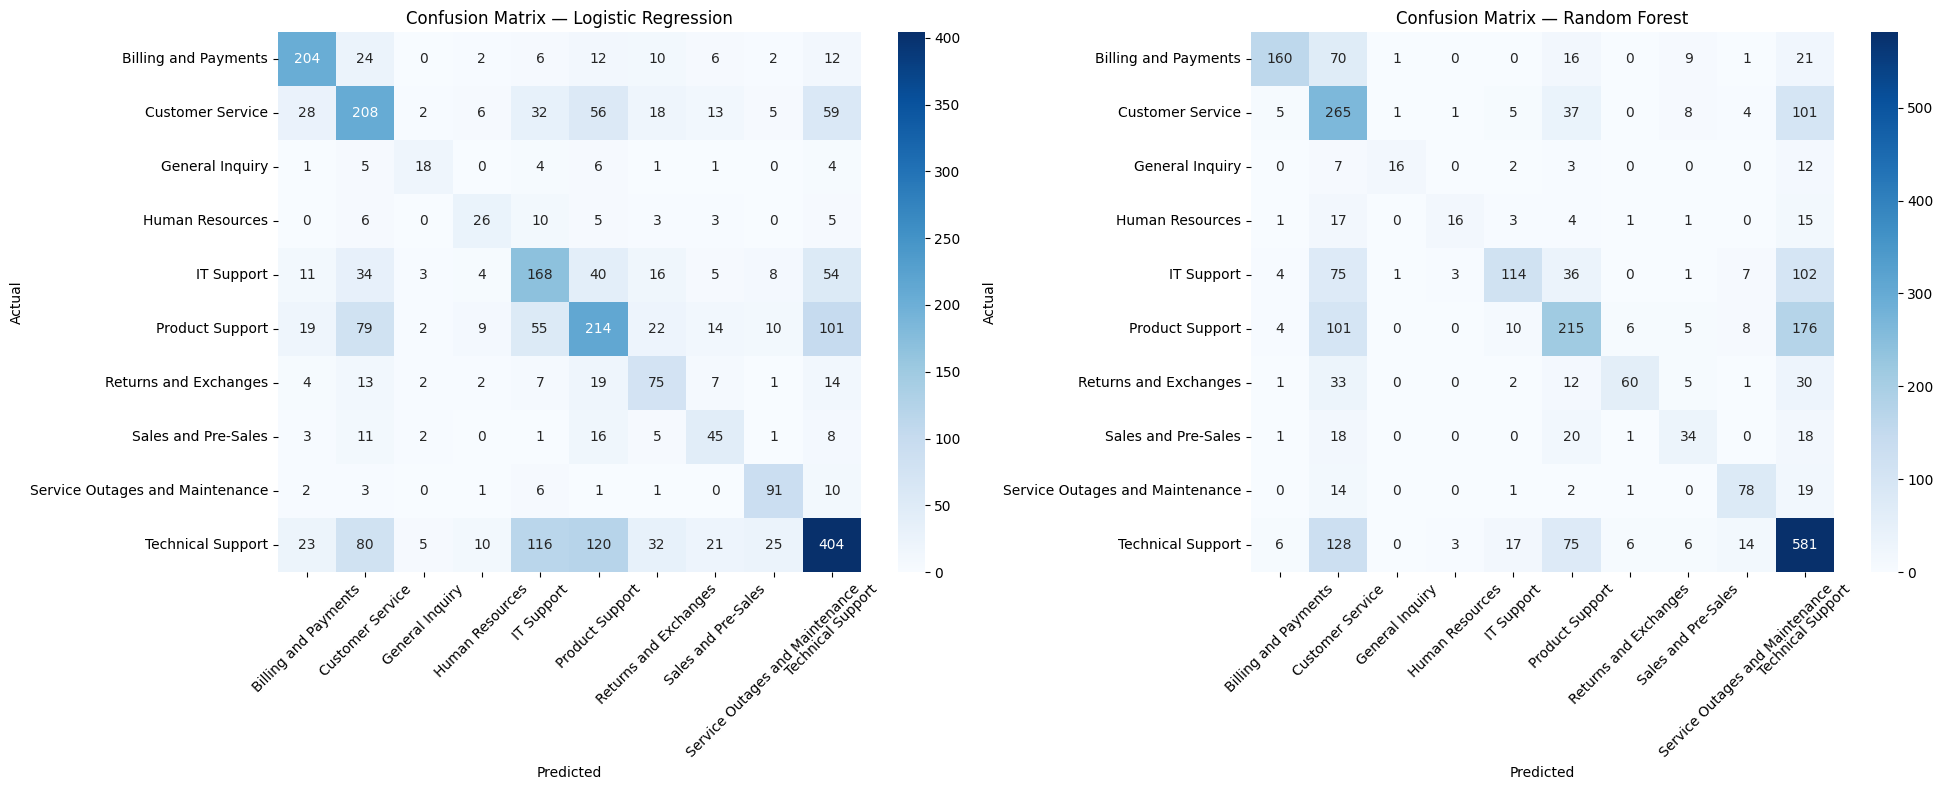

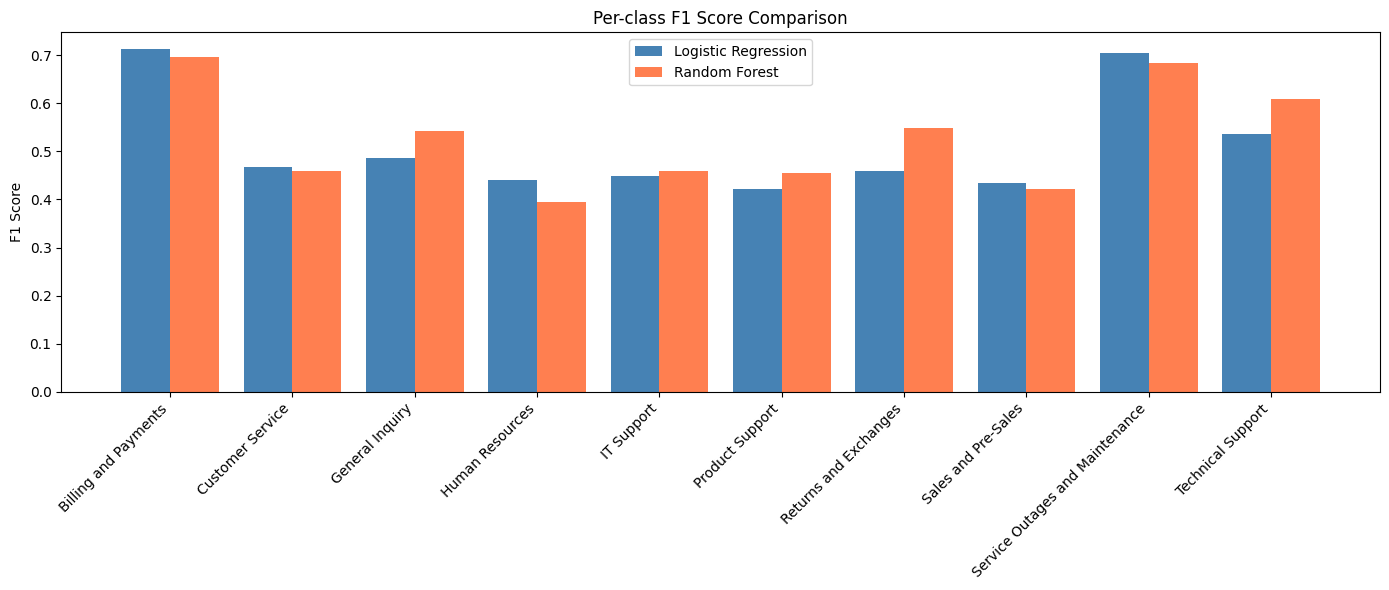


BUSINESS INTERPRETATION OF EVALUATION METRICS

── Logistic Regression ──

  Strongest queue (recall): Service Outages and Maintenance (79%)
    → The model correctly routes 79% of Service Outages and Maintenance tickets. Very few are lost to other teams.

  Weakest queue (recall): Product Support (41%)
    → 59% of Product Support tickets are misrouted to other teams.
    → Business impact: customers in this queue experience delayed resolution
      because their tickets must be manually re-routed, increasing average
      handling time and reducing customer satisfaction.

  Top confusion pairs (most frequent misroutes):
    Technical Support → Product Support: 120 tickets
      These tickets belong to Technical Support but are sent to Product Support.
      The Product Support team receives irrelevant work; the customer waits longer.
    Technical Support → IT Support: 116 tickets
      These tickets belong to Technical Support but are sent to IT Support.
      The IT Support team re

In [260]:
# ── Test: run nodes 1–4 sequentially ─────────────────────────────────────────
state = preprocess_data({})
state = train_models(state)
state = evaluate_models(state)
state = select_model(state)

print(f"\nSelected model : {state['selected_model_name']}")
print(f"Macro F1       : {state['selected_model_metrics']['macro_f1']:.3f}")
print(f"Rationale      : {state['model_selection_rationale']}")


## Phase 3 — Online Inference Pipeline (Nodes 5–8)
Nodes 5, 6, 7, 8: classify incoming ticket, retrieve similar past tickets (RAG), enrich with order context, generate LLM draft response.

### Node 5 — classify-complaint

In [261]:
# ── Node 5: classify_complaint ────────────────────────────────────────────────
# Governed by: skills/classify-complaint.md

def classify_complaint(state: AgentState) -> AgentState:
    print("[classify-complaint] Starting...")
    ticket_text   = state.get("ticket_text", "")
    ticket_type   = state.get("ticket_type", "Request")
    model         = state["selected_model"]
    label_encoder = state["label_encoder"]
    vectorizer    = state["vectorizer"]

    # Guard: too short to classify
    if not ticket_text or len(ticket_text.split()) < 5:
        print("  Ticket too short — setting Unclassified.")
        return {
            **state,
            "predicted_queue":  "Unclassified",
            "confidence_score": 0.0,
            "ticket_type":      ticket_type,
        }

    X = vectorizer.transform([ticket_text])

    pred_int    = model.predict(X)[0]
    proba       = model.predict_proba(X)[0]
    confidence  = float(proba[pred_int])
    pred_queue  = label_encoder.inverse_transform([pred_int])[0]

    print(f"  Predicted queue : {pred_queue}")
    print(f"  Confidence      : {confidence:.3f}")
    if confidence < 0.5:
        print("  WARNING: low confidence — manual review recommended.")

    print("[classify-complaint] Done.")
    return {
        **state,
        "predicted_queue":  pred_queue,
        "confidence_score": confidence,
        "ticket_type":      ticket_type,
    }

### Node 6 — retrieve-similar-tickets (RAG)

In [262]:
# ── Node 6: retrieve_similar_tickets (RAG) ────────────────────────────────────
# Governed by: skills/retrieve-similar-tickets.md
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_similar_tickets(state: AgentState) -> AgentState:
    """Find top-k similar past tickets via TF-IDF cosine similarity (RAG)."""
    print("[retrieve-similar-tickets] Starting...")
    ticket_text     = state.get("ticket_text", "")
    predicted_queue = state.get("predicted_queue", "")
    vectorizer      = state["vectorizer"]
    label_encoder   = state["label_encoder"]
    corpus_texts    = state.get("rag_corpus_texts", [])
    corpus_answers  = state.get("rag_corpus_answers", [])
    corpus_labels   = state.get("rag_corpus_labels", [])

    if not corpus_texts or not ticket_text:
        print("  No RAG corpus or ticket text — skipping retrieval.")
        return {**state, "rag_matches": []}

    # TF-IDF transform the incoming ticket and the training corpus
    ticket_vec  = vectorizer.transform([ticket_text])
    corpus_vecs = vectorizer.transform(corpus_texts)

    # Cosine similarity between ticket and every training example
    sims = cosine_similarity(ticket_vec, corpus_vecs).flatten()

    # Try to filter to same predicted queue
    top_k = 3
    try:
        queue_label = label_encoder.transform([predicted_queue])[0]
    except ValueError:
        queue_label = None

    if queue_label is not None:
        mask = np.array(corpus_labels) == queue_label
        if mask.sum() >= top_k:
            filtered_idx  = np.where(mask)[0]
            filtered_sims = sims[filtered_idx]
            top_local     = np.argsort(filtered_sims)[-top_k:][::-1]
            top_indices   = filtered_idx[top_local]
        else:
            top_indices = np.argsort(sims)[-top_k:][::-1]
    else:
        top_indices = np.argsort(sims)[-top_k:][::-1]

    # Build matches list (truncated for LLM prompt budget)
    matches = []
    for idx in top_indices:
        matches.append({
            "text":       corpus_texts[idx][:300],
            "answer":     corpus_answers[idx][:500],
            "similarity": float(sims[idx]),
        })

    for i, m in enumerate(matches, 1):
        print(f"  Match {i}: sim={m['similarity']:.3f}, text={m['text'][:80]}...")

    print("[retrieve-similar-tickets] Done.")
    return {**state, "rag_matches": matches}

### Node 7 — lookup-order-record

In [263]:
# ── Node 7: lookup_order_record ───────────────────────────────────────────────
# Governed by: skills/lookup-order-record.md

def lookup_order_record(state: AgentState) -> AgentState:
    print("[lookup-order-record] Starting...")
    ticket_id   = state.get("ticket_id")
    mock_orders = state.get("mock_orders")

    if ticket_id is None or mock_orders is None:
        print("  No ticket_id or mock_orders — skipping lookup.")
        return {**state, "order_context": {"error": "No order record found for this ticket ID"}}

    match = mock_orders[mock_orders["ticket_id"] == ticket_id]
    if match.empty:
        print(f"  No record found for ticket_id={ticket_id}.")
        return {**state, "order_context": {"error": f"No order record found for ticket_id={ticket_id}"}}

    row = match.iloc[0]
    order_context = {
        "customer_id":        row["customer_id"],
        "customer_name":      row["customer_name"],
        "account_status":     row["account_status"],
        "product":            row["product"],
        "plan":               row["plan"],
        "region":             row["region"],
        "open_tickets":       int(row["open_tickets"]),
        "last_order_date":    row["last_order_date"],
        "contract_value_usd": int(row["contract_value_usd"]),
    }
    print(f"  Found: {order_context['customer_name']} | {order_context['account_status']} | ${order_context['contract_value_usd']:,}")
    if order_context["contract_value_usd"] >= 9600:
        print("  HIGH-VALUE customer — flagging for priority handling.")
    if order_context["account_status"] in ("Suspended", "Cancelled"):
        print(f"  ACCOUNT STATUS: {order_context['account_status']} — flagging for attention.")

    print("[lookup-order-record] Done.")
    return {**state, "order_context": order_context}


### Node 8 — draft-response (LLM)

In [264]:
# ── Node 8: draft_response ────────────────────────────────────────────────────
# Governed by: skills/draft-response.md  (llm_driven)
# API key loaded from Google Colab Secrets (key name: OPENAI_API_KEY)

import os
from openai import OpenAI

def _get_openai_client():
    """Load API key from Colab Secrets if available, else environment variable."""
    try:
        from google.colab import userdata
        api_key = userdata.get("OPENAI_API_KEY")
    except Exception:
        api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        raise ValueError("OPENAI_API_KEY not found. Add it to Colab Secrets or set as env variable.")
    return OpenAI(api_key=api_key)

def draft_response(state: AgentState) -> AgentState:
    print("[draft-response] Starting...")
    ticket_text     = state.get("ticket_text", "")
    ticket_type     = state.get("ticket_type", "Request")
    predicted_queue = state.get("predicted_queue", "General Inquiry")
    confidence      = state.get("confidence_score", 0.0)
    order_context   = state.get("order_context", {})
    rag_matches     = state.get("rag_matches", [])
    skill_text      = skills.get("draft-response", "")

    # Guard: empty ticket
    if not ticket_text or len(ticket_text.split()) < 5:
        draft = "We received your message but need more details. Please describe your issue."
        print("[draft-response] Done (empty ticket).")
        return {**state, "draft_response": draft}

    # Build order context string for prompt
    if "error" in order_context:
        order_str = "No customer record found — proceed without personalisation."
    else:
        order_str = "\n".join(f"  {k}: {v}" for k, v in order_context.items())

    low_conf_note = (
        "\nNote: classification confidence is low — please review routing manually."
        if confidence < 0.5 else ""
    )

    system_prompt = f"""You are RouteIQ, an intelligent customer support routing assistant.
Follow the policy below exactly when generating your response.

--- SKILL POLICY ---
{skill_text}
--- END POLICY ---"""
    # Build RAG context from similar past tickets
    if rag_matches:
        rag_lines = []
        for i, m in enumerate(rag_matches, 1):
            rag_lines.append(f"--- Similar Ticket {i} (similarity: {m['similarity']:.2f}) ---")
            rag_lines.append(f"Ticket: {m['text']}")
            rag_lines.append(f"Past Response: {m['answer']}")
        rag_context = "\n".join(rag_lines)
    else:
        rag_context = "No similar past tickets found."

    user_prompt = f"""Generate a routing recommendation and draft reply for the following ticket.

Ticket Type: {ticket_type}
Predicted Queue: {predicted_queue}
Confidence: {confidence*100:.1f}%{low_conf_note}

Customer Order Context:
{order_str}

Similar Past Tickets (use these as reference for tone, structure, and content):
{rag_context}

Original Ticket Text:
{ticket_text}

Use the output format specified in the skill policy exactly."""

    client = _get_openai_client()

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        temperature=0.3,
        max_tokens=600,
    )
    draft = response.choices[0].message.content.strip()
    print(f"  Draft response generated ({len(draft)} chars).")
    print("[draft-response] Done.")
    return {**state, "draft_response": draft}

## LangGraph Pipeline Assembly
Wire all 8 nodes into a single end-to-end compiled graph.

In [265]:
from langgraph.graph import StateGraph, START, END

# ── Single end-to-end pipeline: all 8 nodes ──────────────────────────────────
pipeline = StateGraph(AgentState)

# Offline training nodes
pipeline.add_node("preprocess_data",      preprocess_data)
pipeline.add_node("train_models",         train_models)
pipeline.add_node("evaluate_models",      evaluate_models)
pipeline.add_node("select_model",         select_model)

# Online inference nodes
pipeline.add_node("classify_complaint",          classify_complaint)
pipeline.add_node("retrieve_similar_tickets",    retrieve_similar_tickets)
pipeline.add_node("lookup_order_record",         lookup_order_record)
pipeline.add_node("draft_response",              draft_response)

# Wire all nodes in sequence
pipeline.add_edge(START,                          "preprocess_data")
pipeline.add_edge("preprocess_data",              "train_models")
pipeline.add_edge("train_models",                 "evaluate_models")
pipeline.add_edge("evaluate_models",              "select_model")
pipeline.add_edge("select_model",                 "classify_complaint")
pipeline.add_edge("classify_complaint",           "retrieve_similar_tickets")
pipeline.add_edge("retrieve_similar_tickets",     "lookup_order_record")
pipeline.add_edge("lookup_order_record",          "draft_response")
pipeline.add_edge("draft_response",               END)


app = pipeline.compile()
print("Pipeline compiled: preprocess → train → evaluate → select → classify → retrieve → lookup → draft")

Pipeline compiled: preprocess → train → evaluate → select → classify → retrieve → lookup → draft


### Run End-to-End Pipeline
Invoke the full 8-node pipeline with a sample ticket. The pipeline runs offline training (nodes 1–4) then online inference (nodes 5–8) in one pass.

[preprocess-data] Starting...
  Loaded: 28,587 rows x 16 columns
  Dropped 7 rows with missing answer. Remaining: 28,580
  Classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
  Train: 22,866 | Val: 2,856 | Test: 2,858
  TF-IDF shapes — Train: (22866, 10000), Val: (2856, 10000), Test: (2858, 10000)
  RAG corpus: 22,866 texts with answers
[preprocess-data] Done.
[train-models] Starting...
  GridSearch — Logistic Regression...
Fitting 1 folds for each of 5 candidates, totalling 5 fits
  Best C=10.0, Val Macro F1=0.495
  LR trained.
  GridSearch — Random Forest...
Fitting 1 folds for each of 6 candidates, totalling 6 fits
  Best RF={'max_depth': 40, 'n_estimators': 300}, Val Macro F1=0.508
  RF trained.
[train-models] Done.
[evaluate-models] Starting...
  Logistic Regression — Macro F1: 0.511 | Weighted F1: 0.509 | 

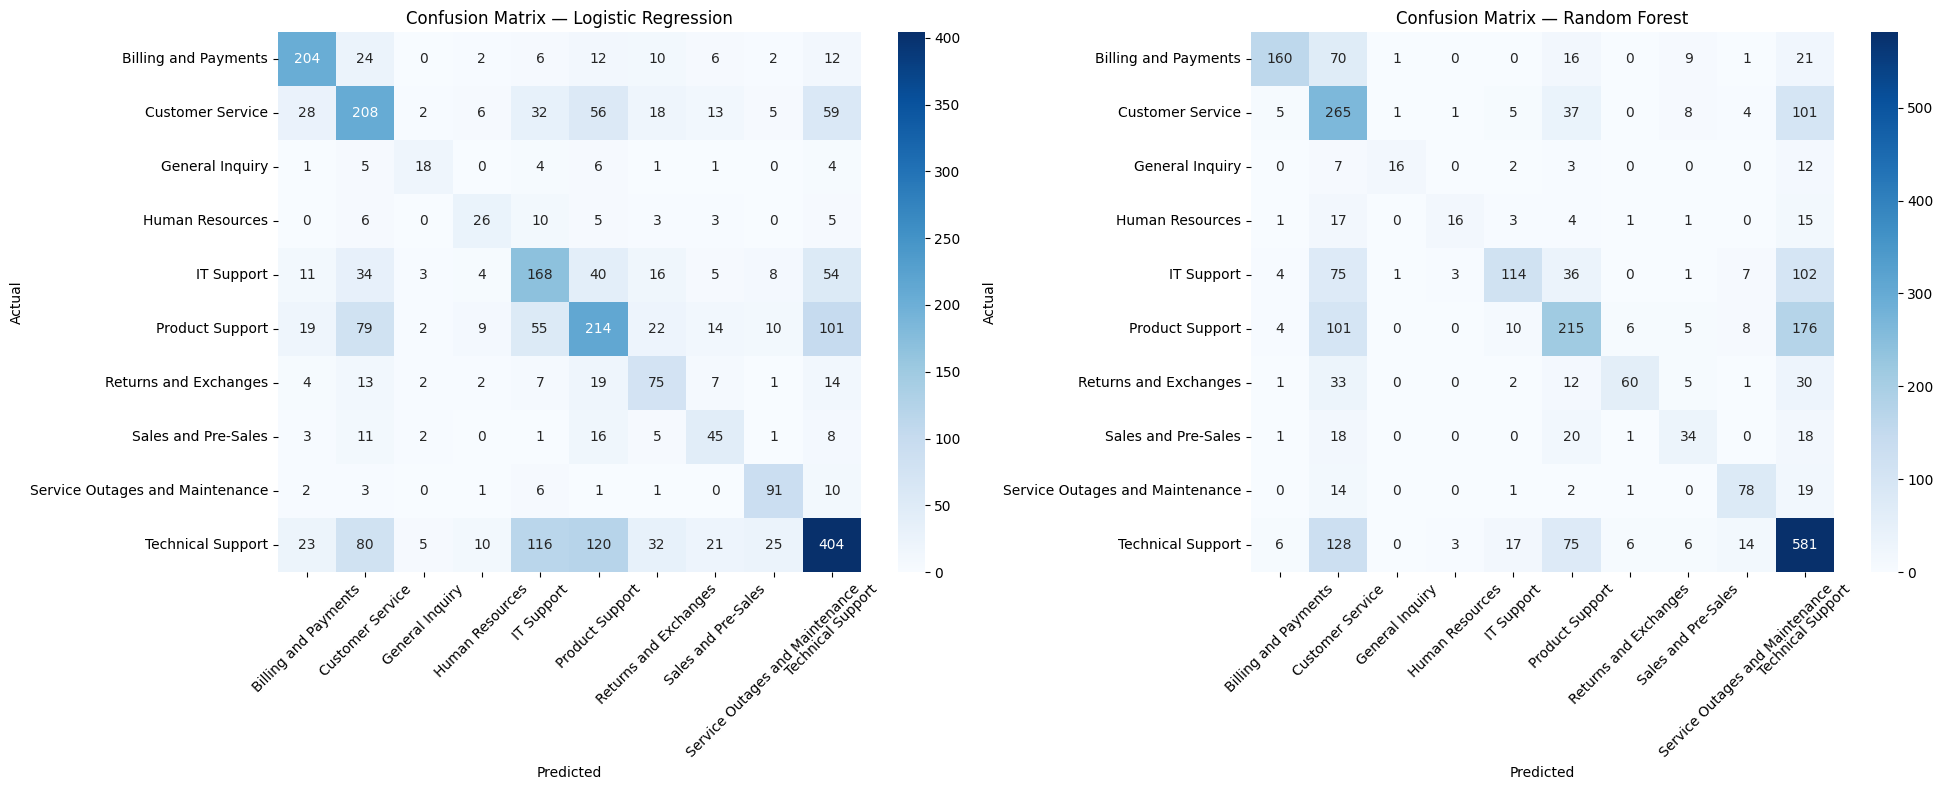

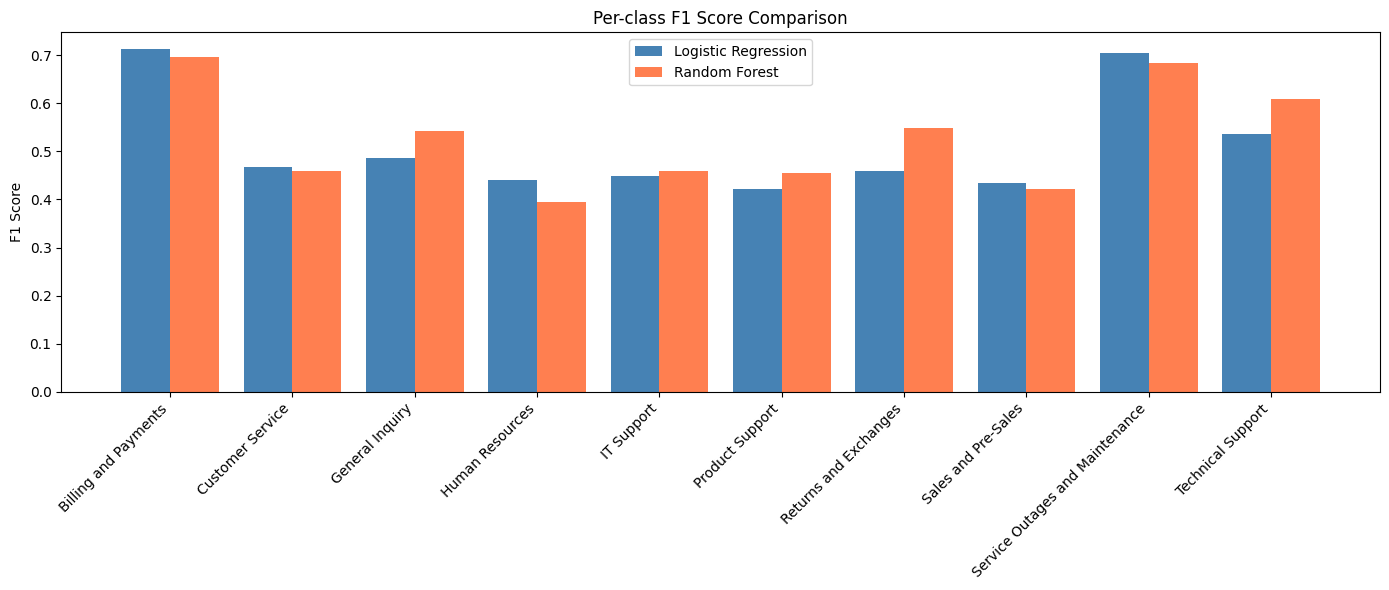


BUSINESS INTERPRETATION OF EVALUATION METRICS

── Logistic Regression ──

  Strongest queue (recall): Service Outages and Maintenance (79%)
    → The model correctly routes 79% of Service Outages and Maintenance tickets. Very few are lost to other teams.

  Weakest queue (recall): Product Support (41%)
    → 59% of Product Support tickets are misrouted to other teams.
    → Business impact: customers in this queue experience delayed resolution
      because their tickets must be manually re-routed, increasing average
      handling time and reducing customer satisfaction.

  Top confusion pairs (most frequent misroutes):
    Technical Support → Product Support: 120 tickets
      These tickets belong to Technical Support but are sent to Product Support.
      The Product Support team receives irrelevant work; the customer waits longer.
    Technical Support → IT Support: 116 tickets
      These tickets belong to Technical Support but are sent to IT Support.
      The IT Support team re

In [266]:
# ── Run the full end-to-end pipeline ──────────────────────────────────────────
result = app.invoke({
    "ticket_text": "I was charged twice for my subscription last month and need a refund.",
    "ticket_type": "Incident",
    "ticket_id":   42,
})

print(f"\n{'='*60}")
print(f"Selected model : {result['selected_model_name']}")
print(f"Macro F1       : {result['selected_model_metrics']['macro_f1']:.3f}")
print(f"Rationale      : {result['model_selection_rationale']}")
print(f"{'='*60}")
print(f"Predicted queue : {result['predicted_queue']}")
print(f"Confidence      : {result['confidence_score']:.3f}")
print(f"Order context   : {result.get('order_context', {})}")
print(f"{'='*60}")
print(f"Draft response:\n{result['draft_response']}")

### Inference Examples
Reuse the trained state from the end-to-end run to classify additional tickets without retraining.
We build a lightweight inference-only pipeline (nodes 5–8) and demonstrate it on diverse ticket types.

In [267]:
# ── Phase 5 Test Cases: three structured inference runs (clear / ambiguous / edge) ──
# Reuse the trained state (result) from the end-to-end run above.

# Build a lightweight inference sub-graph (nodes 5–8 only)
inference_graph = StateGraph(AgentState)
inference_graph.add_node("classify_complaint",       classify_complaint)
inference_graph.add_node("retrieve_similar_tickets", retrieve_similar_tickets)
inference_graph.add_node("lookup_order_record",      lookup_order_record)
inference_graph.add_node("draft_response",           draft_response)
inference_graph.add_edge(START,                      "classify_complaint")
inference_graph.add_edge("classify_complaint",       "retrieve_similar_tickets")
inference_graph.add_edge("retrieve_similar_tickets", "lookup_order_record")
inference_graph.add_edge("lookup_order_record",      "draft_response")
inference_graph.add_edge("draft_response",           END)
inference_app = inference_graph.compile()

# Carry trained artefacts forward (no retraining)
trained_state = {
    k: result[k]
    for k in [
        "vectorizer", "label_encoder", "selected_model",
        "selected_model_name", "mock_orders",
        "rag_corpus_texts", "rag_corpus_answers", "rag_corpus_labels",
    ]
}

# Three test cases aligned with Phase 5 testing plan — taken directly from the dataset:
#   Test 1 — Clear:     dataset index 60,   queue=Billing and Payments, unambiguous billing keywords
#   Test 2 — Ambiguous: dataset index 24,   queue=Technical Support, but describes network connectivity
#                       (could plausibly route to IT Support or Network and Connectivity)
#   Test 3 — Edge case: dataset index 1547, queue=Technical Support, only 4 words — very short/unclear
example_tickets = [
    {
        "label":       "Test 1 — Clear (dataset idx=60, expected: Billing and Payments)",
        "ticket_text": "Discrepancies in Recent Billing Statement Dear Customer Support,\n\nI am submitting a report concerning errors in the latest billing statement. It seems that the automated billing system may have incorrectly allocated hardware purchases among different departmental accounts. I have meticulously examined the invoice and identified entries that do not correspond to our departmental expenses.",
        "ticket_type": "Incident",
        "ticket_id":   60,
    },
    {
        "label":       "Test 2 — Ambiguous (dataset idx=24, labelled Technical Support but describes network connectivity)",
        "ticket_text": "Network Connection Problems Dear Customer Support Team,\n\nI am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow. I've observed sporadic interruptions across several devices, which I believe may be caused by a malfunctioning repeater or router.",
        "ticket_type": "Incident",
        "ticket_id":   24,
    },
    {
        "label":       "Test 3 — Edge case (dataset idx=1547, only 4 words, no order record)",
        "ticket_text": "Issue Encountered Assistance Needed",
        "ticket_type": "Problem",
        "ticket_id":   1547,
    },
]

for i, ticket in enumerate(example_tickets, 1):
    label = ticket.pop("label")
    print(f"\n{'='*70}")
    print(f"TEST {i}: {label}")
    print(f"{'='*70}")
    print(f"  Input : {ticket['ticket_text']}")
    out = inference_app.invoke({**trained_state, **ticket})
    print(f"  Predicted queue : {out['predicted_queue']}")
    print(f"  Confidence      : {out['confidence_score']:.3f}")
    order = out.get("order_context", {})
    if "error" not in order:
        print(f"  Order context   : {order}")

    # Show RAG-retrieved similar tickets
    rag = out.get("rag_matches", [])
    if rag:
        print(f"\n  --- Similar Past Tickets (RAG top-{len(rag)}) ---")
        for j, m in enumerate(rag, 1):
            print(f"  [{j}] similarity={m['similarity']:.3f}")
            print(f"      Ticket : {m['text'][:120]}...")
            print(f"      Answer : {m['answer'][:120]}...")

    print(f"\n  --- Draft Response ---\n{out['draft_response']}")
    print()


TEST 1: Test 1 — Clear (dataset idx=60, expected: Billing and Payments)
  Input : Discrepancies in Recent Billing Statement Dear Customer Support,

I am submitting a report concerning errors in the latest billing statement. It seems that the automated billing system may have incorrectly allocated hardware purchases among different departmental accounts. I have meticulously examined the invoice and identified entries that do not correspond to our departmental expenses.
[classify-complaint] Starting...
  Predicted queue : Billing and Payments
  Confidence      : 0.730
[classify-complaint] Done.
[retrieve-similar-tickets] Starting...
  Match 1: sim=0.647, text=Discrepancies in Recent Billing Statement Dear Customer Support,\n\nI am submitt...
  Match 2: sim=0.576, text=Problem with the latest billing statement There seems to be an issue with the la...
  Match 3: sim=0.469, text=Issues with Billing Statement There was a discrepancy in our last billing statem...
[retrieve-similar-tickets] 

## Gradio UI
Exposes the inference pipeline to non-technical business users.  
The user enters a ticket's text, selects the ticket type, and (optionally) provides a ticket ID.  
The UI returns the predicted queue, confidence score, customer context, and an LLM-drafted routing recommendation.

In [ ]:
import gradio as gr

def route_ticket(ticket_text: str, ticket_type: str, ticket_id: str):
    """Run the inference pipeline and return formatted results."""
    if not ticket_text or len(ticket_text.split()) < 5:
        return "Please enter at least 5 words.", "", "", "", ""

    tid = None
    if ticket_id.strip():
        try:
            tid = int(ticket_id.strip())
        except ValueError:
            return "Ticket ID must be a number.", "", "", "", ""

    input_state = {
        **trained_state,
        "ticket_text": ticket_text,
        "ticket_type": ticket_type,
        "ticket_id":   tid,
    }

    out = inference_app.invoke(input_state)

    queue_str = f"**{out['predicted_queue']}**"
    conf = out["confidence_score"]
    if conf < 0.5:
        conf_str = f"{conf:.1%} — Low confidence. Manual review recommended."
    else:
        conf_str = f"{conf:.1%}"

    order = out.get("order_context", {})
    if "error" in order:
        order_str = order["error"]
    else:
        order_str = (
            f"**Customer:** {order['customer_name']} ({order['customer_id']})\n"
            f"**Account:** {order['account_status']} | **Product:** {order['product']} ({order['plan']})\n"
            f"**Region:** {order['region']} | **Contract:** ${order['contract_value_usd']:,}\n"
            f"**Open tickets:** {order['open_tickets']} | **Last order:** {order['last_order_date']}"
        )

    rag = out.get("rag_matches", [])
    if rag:
        rag_lines = []
        for j, m in enumerate(rag, 1):
            rag_lines.append(f"**[{j}] Similarity: {m['similarity']:.3f}**")
            rag_lines.append(f"  Ticket: {m['text'][:200]}...")
            rag_lines.append(f"  Past Answer: {m['answer'][:200]}...")
            rag_lines.append("")
        rag_str = "\n".join(rag_lines)
    else:
        rag_str = "*No similar past tickets found.*"

    draft = out.get("draft_response", "No response generated.")

    return queue_str, conf_str, order_str, rag_str, draft


def show_loading():
    loading_html = """
    <div class="loading-block">
      <div class="spinner"></div>
      <p>Loading, please wait for the results</p>
    </div>
    """
    return gr.update(value=loading_html, visible=True), gr.update(visible=False)


def route_and_show(ticket_text, ticket_type, ticket_id):
    queue_str, conf_str, order_str, rag_str, draft = route_ticket(ticket_text, ticket_type, ticket_id)
    return (
        gr.update(visible=False),
        gr.update(visible=True),
        queue_str, conf_str, order_str, rag_str, draft,
    )


def build_pipeline_diagram():
    return """
```
+------------------------------------------------------------------+
|                  RouteIQ -- LangGraph Pipeline                   |
+------------------------------------------------------------------+
|                                                                  |
|  +------------------+    +------------------+                   |
|  | 1. preprocess    |--->| 2. train_models  |                   |
|  |    data          |    |  (GridSearchCV)  |                   |
|  |  Load CSV        |    |  Logistic Reg.   |                   |
|  |  TF-IDF (10k)    |    |  Random Forest   |                   |
|  |  80/10/10 split  |    |  PredefinedSplit |                   |
|  +------------------+    +--------+---------+                   |
|                                    |                             |
|  +------------------+    +---------v--------+                   |
|  | 4. select_model  |<---| 3. evaluate      |                   |
|  |  Best Macro F1   |    |    models        |                   |
|  |  Trade-off anlys |    |  Per-class P/R/F1|                   |
|  |  Business impact |    |  Confusion matrix|                   |
|  +--------+---------+    +------------------+                   |
|           |                                                      |
|  =========|==================================================    |
|  OFFLINE  |  ONLINE (per-ticket inference)                       |
|  =========|==================================================    |
|           |                                                      |
|  +---------v--------+    +------------------+                   |
|  | 5. classify      |--->| 5b. retrieve     |                   |
|  |    complaint     |    |  similar_tickets |                   |
|  |  TF-IDF transform|    |  RAG: TF-IDF     |                   |
|  |  predict + proba |    |  cosine sim.     |                   |
|  |  Confidence check|    |  Top-3 matches   |                   |
|  +------------------+    +--------+---------+                   |
|                                    |                             |
|  +------------------+    +---------v--------+                   |
|  | 7. draft_response|<---| 6. lookup_order  |                   |
|  |  (LLM-driven)    |    |    record        |                   |
|  |  GPT-4o-mini     |    |  Mock CRM lookup |                   |
|  |  SKILL.md policy |    |  Customer context|                   |
|  |  RAG few-shot    |    |  High-value flag |                   |
|  +------------------+    +------------------+                   |
|                                                                  |
+------------------------------------------------------------------+
```
"""


def build_model_performance_md():
    comp = result.get("comparison_table")
    rationale = result.get("model_selection_rationale", "N/A")
    selected  = result.get("selected_model_name", "N/A")
    metrics   = result.get("selected_model_metrics", {})

    lines = []
    lines.append("## Model Comparison\n")
    if comp is not None:
        lines.append("| Model | Macro F1 | Weighted F1 | Accuracy |")
        lines.append("|-------|----------|-------------|----------|")
        for _, row in comp.iterrows():
            lines.append(
                f"| {row['Model']} | {row['macro_f1']:.3f} | "
                f"{row['weighted_f1']:.3f} | {row['accuracy']:.3f} |"
            )
        lines.append("")

    lines.append(f"## Selected Model: **{selected}**\n")
    if metrics:
        lines.append(f"- **Macro F1:** {metrics.get('macro_f1', 0):.3f}")
        lines.append(f"- **Weighted F1:** {metrics.get('weighted_f1', 0):.3f}")
        lines.append(f"- **Accuracy:** {metrics.get('accuracy', 0):.3f}")
        lines.append("")

    lines.append("## Selection Rationale\n")
    lines.append(rationale)
    lines.append("")

    pcm = result.get("per_class_metrics")
    if pcm is not None:
        sel_pcm = pcm[pcm["Model"] == selected]
        lines.append(f"\n## Per-class F1 — {selected}\n")
        lines.append("| Queue | Precision | Recall | F1 | Support |")
        lines.append("|-------|-----------|--------|----|---------|")
        for _, row in sel_pcm.iterrows():
            lines.append(
                f"| {row['Queue']} | {row['Precision']:.3f} | "
                f"{row['Recall']:.3f} | {row['F1']:.3f} | {int(row['Support'])} |"
            )

    return "\n".join(lines)


# ── Custom CSS ─────────────────────────────────────────────────────────────
CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;500;600&family=Barlow:wght@600;700;800&family=IBM+Plex+Mono:wght@400;500&display=swap');

:root {
    --bg:        #09090b;
    --surface:   #111115;
    --elevated:  #17171c;
    --border:    #252530;
    --border-hi: #333340;
    --red:       #dc2626;
    --red-hi:    #ef4444;
    --red-dim:   rgba(220,38,38,0.12);
    --text:      #ededf0;
    --text-2:    #80808c;
    --text-3:    #42424e;
    --sans:      'IBM Plex Sans', system-ui, sans-serif;
    --display:   'Barlow', system-ui, sans-serif;
    --mono:      'IBM Plex Mono', 'Courier New', monospace;
}

/* Global */
.gradio-container {
    background: var(--bg) !important;
    font-family: var(--sans) !important;
    max-width: 1100px !important;
    color: var(--text) !important;
}
body, .main { background: var(--bg) !important; }
* { box-sizing: border-box; }

/* Header */
.riq-header {
    padding: 28px 40px 24px;
    position: relative;
    margin-bottom: 0;
}
.riq-header::after {
    content: '';
    position: absolute;
    bottom: 0; left: 40px; right: 40px;
    height: 1px;
    background: linear-gradient(90deg, var(--red) 0%, var(--border) 60%);
}
.riq-eyebrow {
    font-family: var(--mono);
    font-size: 10px;
    font-weight: 500;
    letter-spacing: 0.18em;
    text-transform: uppercase;
    color: var(--red);
    margin-bottom: 10px;
}
.riq-eyebrow .dot {
    display: inline-block;
    width: 6px; height: 6px;
    border-radius: 50%;
    background: #22c55e;
    margin-right: 8px;
    vertical-align: middle;
    animation: blink 2.5s ease-in-out infinite;
}
@keyframes blink { 0%,100%{opacity:1} 50%{opacity:0.3} }
.riq-header h1 {
    font-family: var(--display) !important;
    font-size: 2.1rem !important;
    font-weight: 800 !important;
    color: var(--text) !important;
    margin: 0 0 8px !important;
    letter-spacing: -0.03em;
    line-height: 1.1;
}
.riq-header h1 span { color: var(--red); }
.riq-header p {
    color: var(--text-2) !important;
    font-size: 0.875rem !important;
    margin: 0 !important;
    font-weight: 400;
    line-height: 1.5;
    max-width: 580px;
}

/* Tabs */
.tabs { border: none !important; background: transparent !important; }
.tab-nav {
    background: transparent !important;
    border-bottom: 1px solid var(--border) !important;
    padding: 0 16px !important;
    gap: 0 !important;
}
.tab-nav button {
    font-family: var(--mono) !important;
    font-size: 0.7rem !important;
    font-weight: 500 !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    color: var(--text-3) !important;
    background: transparent !important;
    border: none !important;
    border-bottom: 2px solid transparent !important;
    border-radius: 0 !important;
    padding: 14px 18px !important;
    margin: 0 !important;
    transition: color 0.15s, border-color 0.15s !important;
}
.tab-nav button:hover { color: var(--text-2) !important; }
.tab-nav button.selected {
    color: var(--red) !important;
    border-bottom-color: var(--red) !important;
}
/* Tight tab content — no large top gap */
.tabitem { background: transparent !important; padding: 12px 16px 20px !important; }

/* Form labels */
.block label > span,
label > span {
    font-family: var(--mono) !important;
    font-size: 0.68rem !important;
    font-weight: 500 !important;
    text-transform: uppercase !important;
    letter-spacing: 0.12em !important;
    color: var(--text-3) !important;
    margin-bottom: 6px !important;
    display: block !important;
}

/* Inputs */
textarea, input[type=text], input[type=number], .gr-textbox textarea {
    background: var(--elevated) !important;
    border: 1px solid var(--border) !important;
    border-radius: 3px !important;
    color: var(--text) !important;
    font-family: var(--sans) !important;
    font-size: 0.875rem !important;
    line-height: 1.6 !important;
    transition: border-color 0.15s, box-shadow 0.15s !important;
    caret-color: var(--red) !important;
}
textarea:focus, input:focus {
    border-color: var(--red) !important;
    box-shadow: 0 0 0 3px var(--red-dim) !important;
    outline: none !important;
}
textarea::placeholder, input::placeholder { color: var(--text-3) !important; }

/* Dropdown */
.gr-dropdown .wrap-inner, .gr-dropdown select {
    background: var(--elevated) !important;
    border-color: var(--border) !important;
    color: var(--text) !important;
    font-family: var(--sans) !important;
    font-size: 0.875rem !important;
    border-radius: 3px !important;
}
.gr-dropdown .token { background: var(--red-dim) !important; color: var(--red-hi) !important; }

/* Submit button */
.submit-btn { width: 100% !important; margin-top: 14px !important; }
.submit-btn button {
    background: var(--red) !important;
    color: #fff !important;
    border: none !important;
    border-radius: 3px !important;
    font-family: var(--mono) !important;
    font-size: 0.72rem !important;
    font-weight: 500 !important;
    letter-spacing: 0.15em !important;
    text-transform: uppercase !important;
    padding: 13px 28px !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: background 0.15s, transform 0.1s !important;
}
.submit-btn button:hover { background: #b91c1c !important; transform: translateY(-1px) !important; }
.submit-btn button:active { transform: translateY(0) !important; }
.submit-btn button:disabled { opacity: 0.6 !important; cursor: not-allowed !important; }

/* Loading block */
.loading-block {
    display: flex;
    align-items: center;
    gap: 14px;
    padding: 16px 20px;
    background: var(--elevated);
    border: 1px solid var(--border);
    border-left: 3px solid var(--red);
    border-radius: 3px;
    margin: 12px 0 4px;
}
.spinner {
    width: 16px; height: 16px;
    border: 2px solid var(--border-hi);
    border-top-color: var(--red);
    border-radius: 50%;
    animation: spin 0.65s linear infinite;
    flex-shrink: 0;
}
@keyframes spin { to { transform: rotate(360deg); } }
.loading-block p {
    font-family: var(--mono) !important;
    font-size: 0.72rem !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    color: var(--text-2) !important;
    margin: 0 !important;
}

/* Result cards */
.result-card {
    background: var(--elevated) !important;
    border: 1px solid var(--border) !important;
    border-left: 3px solid var(--red) !important;
    border-radius: 3px !important;
    padding: 18px 20px !important;
    margin: 0 !important;
}
.result-card label > span { color: var(--text-3) !important; }
.result-card .prose p, .result-card p {
    color: var(--text) !important;
    font-size: 0.95rem !important;
    font-weight: 500 !important;
    margin: 0 !important;
}

/* Output card (customer context) */
.output-card {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 3px !important;
    padding: 18px 20px !important;
    margin-top: 10px !important;
}
.output-card .prose p { color: var(--text-2) !important; font-size: 0.875rem !important; }

/* Results divider */
.results-divider {
    border: none !important;
    border-top: 1px solid var(--border) !important;
    margin: 16px 0 14px !important;
    position: relative !important;
}
.results-divider::before {
    content: 'RESULTS';
    position: absolute;
    top: -9px; left: 0;
    font-family: var(--mono);
    font-size: 0.65rem;
    font-weight: 500;
    letter-spacing: 0.15em;
    color: var(--text-3);
    background: var(--bg);
    padding-right: 10px;
}

/* Section label — zero top gap */
.section-label p, .section-label {
    font-family: var(--mono) !important;
    font-size: 0.65rem !important;
    font-weight: 500 !important;
    text-transform: uppercase !important;
    letter-spacing: 0.14em !important;
    color: var(--text-3) !important;
    padding: 0 0 6px !important;
    margin: 0 !important;
}

/* Accordion */
.gr-accordion {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 3px !important;
    margin-top: 10px !important;
}
.gr-accordion .label-wrap span {
    font-family: var(--mono) !important;
    font-size: 0.7rem !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    color: var(--text-2) !important;
}

/* Draft response */
.draft-box textarea {
    font-family: var(--mono) !important;
    font-size: 0.82rem !important;
    line-height: 1.8 !important;
    background: var(--surface) !important;
    color: var(--text) !important;
    border-color: var(--border) !important;
}

/* Markdown / Prose */
.prose, .prose p, .prose li { color: var(--text-2) !important; font-size: 0.875rem !important; line-height: 1.65 !important; }
.prose strong { color: var(--text) !important; }
.prose h2, .prose h3 { color: var(--text) !important; font-family: var(--display) !important; font-weight: 700 !important; margin-top: 1.5em !important; }
.prose table { border-color: var(--border) !important; width: 100%; border-collapse: collapse; }
.prose th {
    background: var(--elevated) !important; color: var(--text-3) !important;
    font-family: var(--mono) !important; font-size: 0.65rem !important;
    letter-spacing: 0.12em !important; text-transform: uppercase !important;
    border: 1px solid var(--border) !important; padding: 10px 14px !important;
}
.prose td { border: 1px solid var(--border) !important; padding: 10px 14px !important; color: var(--text-2) !important; }
.prose tr:hover td { background: var(--elevated) !important; }
.prose pre, pre {
    background: var(--elevated) !important; border: 1px solid var(--border) !important;
    border-radius: 3px !important; padding: 16px 20px !important;
    font-family: var(--mono) !important; font-size: 0.75rem !important;
    line-height: 1.65 !important; color: var(--text-2) !important;
    overflow-x: auto !important;
}
.prose code {
    font-family: var(--mono) !important; color: var(--red-hi) !important;
    background: var(--red-dim) !important; padding: 2px 6px !important;
    border-radius: 2px !important; font-size: 0.82em !important;
}

/* Images */
.gr-image img { border-radius: 3px !important; border: 1px solid var(--border) !important; }

/* Examples */
.gr-samples { background: var(--surface) !important; border: 1px solid var(--border) !important; border-radius: 3px !important; }
.gr-samples tr:hover { background: var(--elevated) !important; }
.gr-samples td { color: var(--text-2) !important; font-size: 0.82rem !important; border-color: var(--border) !important; }
.gr-samples th { font-family: var(--mono) !important; font-size: 0.65rem !important; letter-spacing: 0.1em !important; text-transform: uppercase !important; color: var(--text-3) !important; border-color: var(--border) !important; background: var(--elevated) !important; }

/* Scrollbars */
::-webkit-scrollbar { width: 5px; height: 5px; }
::-webkit-scrollbar-track { background: var(--bg); }
::-webkit-scrollbar-thumb { background: var(--border-hi); border-radius: 2px; }
"""

# ── Build Gradio interface ─────────────────────────────────────────────────
with gr.Blocks(
    title="RouteIQ — Ticket Routing System",
    theme=gr.themes.Base(
        primary_hue="red",
        neutral_hue="zinc",
        font=[gr.themes.GoogleFont("IBM Plex Sans"), "system-ui", "sans-serif"],
        font_mono=[gr.themes.GoogleFont("IBM Plex Mono"), "monospace"],
    ).set(
        body_background_fill="#09090b",
        block_background_fill="#111115",
        block_border_color="#252530",
        block_label_text_color="#42424e",
        input_background_fill="#17171c",
        input_border_color="#252530",
        button_primary_background_fill="#dc2626",
        button_primary_background_fill_hover="#b91c1c",
        button_primary_text_color="#ffffff",
        border_color_primary="#252530",
        shadow_drop="none",
        shadow_spread="0px",
    ),
    css=CUSTOM_CSS,
) as demo:

    gr.HTML("""
    <div class="riq-header">
      <div class="riq-eyebrow"><span class="dot"></span>System Active</div>
      <h1>Route<span>IQ</span></h1>
      <p>Intelligent ticket routing system — LangGraph pipeline with TF-IDF classification, RAG retrieval, and LLM response generation.</p>
    </div>
    """)

    with gr.Tabs():

        with gr.TabItem("Ticket Router"):
            gr.Markdown("Submit a support ticket for automated classification and draft response generation.", elem_classes=["section-label"])

            with gr.Row():
                with gr.Column(scale=2):
                    txt_input = gr.Textbox(
                        label="Ticket Description",
                        placeholder="Describe the issue in detail...",
                        lines=5,
                    )
                with gr.Column(scale=1):
                    type_input = gr.Dropdown(
                        choices=["Incident", "Request", "Problem", "Change"],
                        value="Incident",
                        label="Ticket Type",
                    )
                    id_input = gr.Textbox(
                        label="Ticket ID (Optional)",
                        placeholder="e.g. 42",
                    )
                    submit_btn = gr.Button(
                        "Route Ticket",
                        variant="primary",
                        elem_classes=["submit-btn"],
                        size="lg",
                    )

            # Loading indicator — shown while processing, hidden otherwise
            loading_state = gr.HTML(visible=False)

            # Results section — hidden until first submission
            with gr.Column(visible=False) as results_col:
                gr.HTML('<hr class="results-divider" />')

                with gr.Row():
                    with gr.Column(scale=1, elem_classes=["result-card"]):
                        queue_out = gr.Markdown(label="Predicted Queue")
                    with gr.Column(scale=1, elem_classes=["result-card"]):
                        conf_out = gr.Markdown(label="Confidence Score")

                with gr.Group(elem_classes=["output-card"]):
                    order_out = gr.Markdown(label="Customer Context")

                with gr.Accordion("Similar Past Tickets (RAG)", open=False):
                    rag_out = gr.Markdown(label="RAG Matches")

                draft_out = gr.Textbox(
                    label="Draft Response",
                    lines=6,
                    interactive=False,
                    show_copy_button=True,
                    elem_classes=["draft-box"],
                )

            gr.Markdown("Load an example ticket:", elem_classes=["section-label"])
            gr.Examples(
                examples=[
                    ["Discrepancies in Recent Billing Statement Dear Customer Support,\n\nI am submitting a report concerning errors in the latest billing statement. It seems that the automated billing system may have incorrectly allocated hardware purchases among different departmental accounts.", "Incident", "60"],
                    ["Network Connection Problems Dear Customer Support Team,\n\nI am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow. I've observed sporadic interruptions across several devices.", "Incident", "24"],
                    ["Issue Encountered Assistance Needed", "Problem", "1547"],
                ],
                inputs=[txt_input, type_input, id_input],
            )

            (
                submit_btn
                .click(
                    fn=show_loading,
                    inputs=[],
                    outputs=[loading_state, results_col],
                    queue=False,
                )
                .then(
                    fn=route_and_show,
                    inputs=[txt_input, type_input, id_input],
                    outputs=[loading_state, results_col, queue_out, conf_out, order_out, rag_out, draft_out],
                )
            )

        with gr.TabItem("Pipeline Architecture"):
            gr.Markdown("8-node LangGraph pipeline — offline training (nodes 1–4) and online inference (nodes 5–8).", elem_classes=["section-label"])
            gr.Markdown("## LangGraph Pipeline — 8-Node Architecture")
            gr.Markdown(
                "The pipeline is split into **offline** (training, nodes 1–4) and "
                "**online** (per-ticket inference, nodes 5–8). "
                "Node 5b retrieves similar past tickets (RAG) to ground the LLM response. "
                "Each node is governed by a SKILL.md policy file."
            )
            gr.Markdown(build_pipeline_diagram())
            with gr.Group(elem_classes=["output-card"]):
                gr.Markdown(
                    "**Key design choices:**\n"
                    "- TF-IDF with 10,000 features, bigrams, EN+DE stopwords\n"
                    "- GridSearchCV with PredefinedSplit (no data leakage)\n"
                    "- RAG retrieval: TF-IDF cosine similarity over training corpus for few-shot LLM grounding\n"
                    "- Confidence threshold (< 50%) flags uncertain predictions for human review\n"
                    "- SKILL.md files decouple business policy from code logic"
                )

        with gr.TabItem("Model Performance"):
            gr.Markdown("Evaluation results for Logistic Regression and Random Forest across 10 support queues.", elem_classes=["section-label"])
            gr.Markdown(build_model_performance_md())
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Confusion Matrices")
                    try:
                        gr.Image(os.path.join(IMAGE_DIR, "confusion_matrices.png"), label="Confusion Matrices")
                    except Exception:
                        gr.Markdown("*Run the pipeline first to generate confusion matrix plots.*")
                with gr.Column():
                    gr.Markdown("### Per-class F1 Comparison")
                    try:
                        gr.Image(os.path.join(IMAGE_DIR, "per_class_f1.png"), label="Per-class F1")
                    except Exception:
                        gr.Markdown("*Run the pipeline first to generate per-class F1 plot.*")

demo.queue()
demo.launch(share=True)
